In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [2]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/load.code.env.R")


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers




In [3]:
path_ref <- '/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds'
dmg <- readRDS(path_ref)
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [7]:
dmg <- subset(dmg, Study=='Ruiz2023')
dmg

An object of class Seurat 
19248 features across 205805 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <-  subset(dmg, lvl_2 %in% c('Stem_like',
                                  'Differentiated_like',
                                  'Myeloid'))

In [10]:
sussman2024_malignant <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_malignant.RDS')

In [11]:
sussman2024_myeloid <- readRDS('/projects/0/einf2548/cruiz/dmg/public_data/Sussman2024/Final_Cohort_All_snRNA-seq_H3K27_H3WT_myeloid.RDS')

In [12]:
sussman2024 <- merge(sussman2024_malignant, sussman2024_myeloid)

In [ ]:
# Extract metadata from each Seurat object
metadata1 <- dmg@meta.data
metadata2 <- sussman2024@meta.data

# Merge metadata with full outer join on common columns
merged_metadata <- full_join(metadata1, metadata2, by = intersect(names(metadata1), names(metadata2)))
rownames(merged_metadata) <- merged_metadata$cell

merged_metadata

In [16]:
length(unique(merged_metadata$patient_id))

[1] 51

In [17]:
length(unique(merged_metadata$patient_id_detailed))

[1] 104

In [18]:
table(merged_metadata$lvl_4)


        AC_like      Cilia_like        COP_like         GB_like         GW_like 
          52323            9061            2120            9948           28755 
Mono_neutrophil       nIPC_like        OPC_like         RG_like         TAM_C1Q 
           2362           14847           80778          105844            2927 
TAM_homeostatic        TAM_IL1B TAM_lipid_laden   TAM_scavenger         TD_like 
          12397            4420            9788           21749           56051 
   Tri_IPC_like 
          20279 

In [19]:
merged_metadata$lvl_4 <- as.factor(merged_metadata$lvl_4)
merged_metadata$lvl_4 <- droplevels(recode(merged_metadata$lvl_4,
                               'OPC_like'='opc.0', 
'COP_like'='cop.1', 
'TAM_scavenger'='scav.0', 
'Mono_neutrophil'='neumono.1', 
'TAM_C1Q'='c1q.2', 
'TAM_lipid_laden'='lipid.3', 
'GW_like'='gw.2', 
'TD_like'='td.3', 
'nIPC_like'='ipc.4', 
'GB_like'='gb.5', 
'AC_like'='ac.6', 
'Cilia_like'='cilia.7', 
'Tri_IPC_like'='tri.1', 
'RG_like'='rg.2', 
'TAM_homeostatic'='homeo.4', 
'TAM_IL1B'='il1b.5'            
))

table(merged_metadata$lvl_4)


     ac.6   cilia.7     cop.1      gb.5      gw.2 neumono.1     ipc.4     opc.0 
    52323      9061      2120      9948     28755      2362     14847     80778 
     rg.2     c1q.2   homeo.4    il1b.5   lipid.3    scav.0      td.3     tri.1 
   105844      2927     12397      4420      9788     21749     56051     20279 

In [20]:
# Access the Clinical_status column from the Seurat object metadata
clinical_status <- merged_metadata$Clinical_status

# Update Clinical_status for specific cells based on values in the SampleID column
clinical_status[merged_metadata$SampleID == 'T20-90296_472AAL_diagnosis'] <- 'Primary'
clinical_status[merged_metadata$SampleID %in% c('T20-90296_472AAL_autopsy', 'T20-90296_472AAL_relapse')] <- 'Recurrence'

# Assign the updated Clinical_status back to the Seurat object
merged_metadata$Clinical_status <- factor(clinical_status, levels = unique(clinical_status))

In [21]:
# Step 1: Identify unique values in the SampleID column
unique_sample_ids <- unique(merged_metadata$SampleID)

# Step 2: Generate new de-identified names
new_names <- paste0("projid.", seq_along(unique_sample_ids))

# Step 3: Replace original SampleID values with new de-identified names
for (i in seq_along(unique_sample_ids)) {
  merged_metadata$SampleID[merged_metadata$SampleID == unique_sample_ids[i]] <- new_names[i]
}

In [22]:
data.frame(unique_sample_ids, new_names)

unique_sample_ids,new_names
<chr>,<chr>
BT042_PD,projid.1
BT042_pons_1,projid.2
BT042_pons_2,projid.3
BT072_region_1,projid.4
BT072_region_2,projid.5
BT789AAQ,projid.6
GNG_region_10,projid.7
GNG_region_11,projid.8
GNG_region_12,projid.9


##  Creating subpopulation proportion matrix

In [23]:
df <- merged_metadata %>% filter(Tumor_type=='DMG H3 K27-altered')
df

,nCount_RNA,nFeature_RNA,nCount_RAW,nFeature_RAW,DF.class,DF.score,scDblFinder.class,scDblFinder.score,ID,SampleID,⋯,predicted.dmg.atlas.seuratv4.lvl_4.score,predicted.dmg.atlas.seuratv4.lvl_4,predicted.dmg.atlas.seuratv4.lvl_4_coarse.score,predicted.dmg.atlas.seuratv4.lvl_4_coarse,predicted.dmg.atlas.seuratv4.lvl_5.score,predicted.dmg.atlas.seuratv4.lvl_5,predicted.atlas.score,predicted.atlas,final,cell_labels1
,<dbl>,<int>,<dbl>,<int>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,10775,3338,10838,3366,Singlet,0.10909091,Singlet,0.66635233,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTACCTGGTATGAAAC-1,9031,3613,9139,3644,Singlet,0.12727273,Singlet,0.66635233,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TTGCATTTCCTGTAGA-1,7641,2960,7697,2987,Singlet,0.10909091,Singlet,0.42149284,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GTGCTGGGTAACGCGA-1,7135,3151,7290,3183,Singlet,0.07272727,Doublet,0.98795068,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CTTCTAAAGACGCATG-1,5720,2362,5834,2405,Singlet,0.09090909,Singlet,0.33930978,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTCACACAAAGCTAA-1,5471,1911,5554,1948,Singlet,0.12727273,Singlet,0.31077635,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_TGCGATAAGCCATCCG-1,4960,2065,4994,2080,Singlet,0.10909091,Singlet,0.76924258,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_GAATAGAGTTTATGCG-1,4726,2219,4867,2231,Singlet,0.07272727,Singlet,0.24659014,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
BT042_PD_CCTGCATAGGTCACAG-1,4652,1813,4668,1824,Singlet,0.12727273,Singlet,0.08938396,T18-90532,projid.1,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [24]:
length(unique(df$patient_id))

[1] 35

In [25]:
length(unique(df$patient_id_detailed))

[1] 57

In [26]:
table(df$lvl_2)


Differentiated_like             Myeloid           Stem_like 
              89704               32546               80543 

In [27]:
table(df$lvl_1)


   Immune Malignant 
    32546    170247 

In [28]:
df$class <- df$lvl_1
df$cell.type <- df$lvl_2
df$state <- df$lvl_4
df$grouping.by <- df$lvl_2
df$projid <- df$SampleID

In [29]:
# Calculate participant-wise subpopulation-proportion (within cell-type)
df <- df %>% 
  count(class, grouping.by, cell.type, projid, state) %>%
  group_by(grouping.by, projid) %>%
  mutate(prevalence=n/sum(n)) %>%
  ungroup()
df

class,grouping.by,cell.type,projid,state,n,prevalence
<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<dbl>
Immune,Myeloid,Myeloid,projid.1,neumono.1,7,0.106060606
Immune,Myeloid,Myeloid,projid.1,c1q.2,4,0.060606061
Immune,Myeloid,Myeloid,projid.1,lipid.3,10,0.151515152
Immune,Myeloid,Myeloid,projid.1,scav.0,45,0.681818182
Immune,Myeloid,Myeloid,projid.10,neumono.1,37,0.142307692
Immune,Myeloid,Myeloid,projid.10,c1q.2,2,0.007692308
Immune,Myeloid,Myeloid,projid.10,il1b.5,1,0.003846154
Immune,Myeloid,Myeloid,projid.10,lipid.3,10,0.038461538
Immune,Myeloid,Myeloid,projid.10,scav.0,210,0.807692308


In [30]:
proportions <- dcast(df, projid~state, value.var = "prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid")
proportions

,ac.6,cilia.7,cop.1,gb.5,gw.2,neumono.1,ipc.4,opc.0,rg.2,c1q.2,homeo.4,il1b.5,lipid.3,scav.0,td.3,tri.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,0.0000000000,0.0000000000,0.9166666667,0.0000000000,0.0833333333,0.1060606061,0.000000000,1.0000000,0.0000000000,0.0606060606,0.000000000,0.000000000,0.151515152,0.681818182,0.0000000000,0.0000000000
projid.10,0.1739130435,0.0326086957,0.3260869565,0.2391304348,0.0000000000,0.1423076923,0.076086957,0.9971910,0.0028089888,0.0076923077,0.000000000,0.003846154,0.038461538,0.807692308,0.1521739130,0.0000000000
projid.100,0.2185792350,0.0018214936,0.0000000000,0.0000000000,0.4826958106,0.0000000000,0.001821494,0.8133971,0.1531100478,0.0322580645,0.000000000,0.000000000,0.741935484,0.225806452,0.2950819672,0.0334928230
projid.101,0.3797610157,0.0005601195,0.0524645258,0.0001867065,0.3482076176,0.0034924331,0.017550411,0.7230945,0.2755021489,0.0873108265,0.009313155,0.001164144,0.284051222,0.614668219,0.2012696042,0.0014033857
projid.102,0.3253228121,0.0003586801,0.0383787661,0.0010760402,0.3837876614,0.0000000000,0.006097561,0.9586607,0.0379909852,0.0538922156,0.025449102,0.001497006,0.217065868,0.702095808,0.2449784792,0.0033483580
projid.11,0.0132398754,0.0000000000,0.0000000000,0.0903426791,0.0786604361,0.6661237785,0.028816199,0.8611111,0.1111111111,0.0000000000,0.000000000,0.153094463,0.166123779,0.014657980,0.7889408100,0.0277777778
projid.12,0.6540540541,0.0000000000,0.0108108108,0.0378378378,0.0486486486,0.0000000000,0.037837838,0.9150327,0.0000000000,0.0000000000,0.880000000,0.120000000,0.000000000,0.000000000,0.2108108108,0.0849673203
projid.13,0.5420168067,0.0032679739,0.0009337068,0.0102707750,0.0485527544,0.0023310023,0.036881419,0.9102504,0.0136986301,0.0233100233,0.899766900,0.048951049,0.011655012,0.013986014,0.3580765640,0.0760510156
projid.14,0.8181818182,0.0000000000,0.0101010101,0.0117845118,0.0000000000,0.0027008778,0.005050505,0.9885057,0.0114942529,0.0060769750,0.368669818,0.576637407,0.017555706,0.028359217,0.1548821549,0.0000000000


In [31]:
counts <- dcast(df, projid~state, value.var = "n", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid")
counts

,ac.6,cilia.7,cop.1,gb.5,gw.2,neumono.1,ipc.4,opc.0,rg.2,c1q.2,homeo.4,il1b.5,lipid.3,scav.0,td.3,tri.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,0,0,11,0,1,7,0,14,0,4,0,0,10,45,0,0
projid.10,16,3,30,22,0,37,7,355,1,2,0,1,10,210,14,0
projid.100,120,1,0,0,265,0,1,170,32,1,0,0,23,7,162,7
projid.101,2034,3,281,1,1865,3,94,8244,3141,75,8,1,244,528,1078,16
projid.102,907,1,107,3,1070,0,17,7444,295,36,17,1,145,469,683,26
projid.11,17,0,0,116,101,409,37,31,4,0,0,94,102,9,1013,1
projid.12,121,0,2,7,9,0,7,140,0,0,22,3,0,0,39,13
projid.13,1161,7,2,22,104,1,79,1927,29,10,386,21,5,6,767,161
projid.14,486,0,6,7,0,4,3,86,1,9,546,854,26,42,92,0


In [34]:
ids <- rownames(proportions)
data <- AnnData(
  # Subpopulation proportions: participants (rows) over subpopulations (columns)
  X = proportions,
  
  # Counts and sqrt(prop) of subpopulations
  layers = list(counts = counts[ids, colnames(proportions)],
                sqrt.prev = sqrt(proportions)),
  
  # General information about the different subpopulations
  var = df %>% dplyr::select(class, grouping.by, cell.type, state) %>% unique %>% column_to_rownames("state") %>% `[`(colnames(proportions),),
  
  # # General information about the participants
  # obs = list(batches = df_summary[ids,])
)

In [35]:
data

AnnData object with n_obs × n_vars = 57 × 16
    var: 'class', 'grouping.by', 'cell.type'
    layers: 'counts', 'sqrt.prev'

In [36]:
cell.type.df <- df %>% group_by(projid, class, cell.type) %>%
  dplyr::summarise(n = sum(n), .groups = "drop") %>%
  dplyr::group_by(projid) %>%
  dplyr::mutate(prevalence = n/sum(n)) %>%
  dplyr::group_by(projid, class) %>%
  dplyr::mutate(within.class.prevalence = n/sum(n))

In [37]:
cell.type.df

projid,class,cell.type,n,prevalence,within.class.prevalence
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
projid.1,Immune,Myeloid,66,0.71739130,1.00000000
projid.1,Malignant,Differentiated_like,12,0.13043478,0.46153846
projid.1,Malignant,Stem_like,14,0.15217391,0.53846154
projid.10,Immune,Myeloid,260,0.36723164,1.00000000
projid.10,Malignant,Differentiated_like,92,0.12994350,0.20535714
projid.10,Malignant,Stem_like,356,0.50282486,0.79464286
projid.100,Immune,Myeloid,31,0.03929024,1.00000000
projid.100,Malignant,Differentiated_like,549,0.69581749,0.72427441
projid.100,Malignant,Stem_like,209,0.26489227,0.27572559


In [38]:
ct.counts <- (dcast(cell.type.df, projid~cell.type, value.var = "n", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]
ct.prev   <- (dcast(cell.type.df, projid~cell.type, value.var = "prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]
ct.c.prev <- (dcast(cell.type.df, projid~cell.type, value.var = "within.class.prevalence", fill = 0, fun.aggregate = sum) %>% tibble::column_to_rownames("projid"))[data$obs_names, ]

In [39]:
data$uns$cell.types <- list(counts = ct.counts, 
                            prev = ct.prev, 
                            sqrt.prev = sqrt(ct.prev), 
                            wc.prev = ct.c.prev, 
                            sqrt.wc.prev = sqrt(ct.c.prev))

In [ ]:
meta <- merged_metadata %>% filter(Tumor_type=='DMG H3 K27-altered')
meta

In [41]:
df_summary <- meta %>%
  group_by(SampleID) %>%
  summarize(
    Study = first(Study),
    PatientID = first(patient_id),
    PatientIDdetail = first(patient_id_detailed),
    Preservation_method = first(Preservation_method),
    Diagnosis = first(Diagnosis),
    Tumor_type = first(Tumor_type),
    Tumor_subtype = first(Tumor_subtype),
    Location = first(Location),
    Source = first(Source),
    Clinical_status = first(Clinical_status),
      Timepoint = first(timepoint),
    Paired_sample = first(Paired_sample),
    Multisector = first(Multisector),
    Gender = first(Gender),
    Age_years = mean(Age_years, na.rm = TRUE),
    Dexamethasone_prior_surgery = first(Dexamethasone_prior_surgery)
  ) %>% column_to_rownames("SampleID")
df_summary

Warning message:
“There were 57 warnings in `summarize()`.
The first warning was:
ℹ In argument: `Age_years = mean(Age_years, na.rm = TRUE)`.
ℹ In group 1: `SampleID = "projid.1"`.
Caused by warning in `mean.default()`:
! argument is not numeric or logical: returning NA
ℹ Run `dplyr::last_dplyr_warnings()` to see the 56 remaining warnings.”


,Study,PatientID,PatientIDdetail,Preservation_method,Diagnosis,Tumor_type,Tumor_subtype,Location,Source,Clinical_status,Timepoint,Paired_sample,Multisector,Gender,Age_years,Dexamethasone_prior_surgery
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
projid.1,Ruiz2023,T18-90532,BT042_PD,Cryo,DMG Pons,DMG H3 K27-altered,H3.1 K27-mutant,Pons,Autopsy,Recurrence,NA,N,Y,F,NA,No
projid.10,Ruiz2023,GNG,GNG_region_6,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Autopsy,Recurrence,NA,N,Y,M,NA,Yes
projid.100,Sussman2024,C2751264,HTAN_pHGG_6761_Reg2_snRNA,NA,NA,DMG H3 K27-altered,NA,NA,NA,Primary,Initial CNS Tumor,NA,NA,NA,NA,NA
projid.101,Sussman2024,C2751264,HTAN_pHGG_7622_Reg1_snRNA,NA,NA,DMG H3 K27-altered,NA,NA,NA,Recurrence,Progressive (Autopsy),NA,NA,NA,NA,NA
projid.102,Sussman2024,C2751264,HTAN_pHGG_7622_Reg2_snRNA,NA,NA,DMG H3 K27-altered,NA,NA,NA,Recurrence,Progressive (Autopsy),NA,NA,NA,NA,NA
projid.11,Ruiz2023,T19-90627,T19-90627_466AAL,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NA,N,N,F,NA,Yes
projid.12,Ruiz2023,T19-90673,T19-90673_577AAL_section_1,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NA,N,N,F,NA,No
projid.13,Ruiz2023,T19-90673,T19-90673_577AAL_section_2,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NA,N,N,F,NA,No
projid.14,Ruiz2023,T19-91014,T19-91014_635AAM_core,Cryo,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NA,N,Y,M,NA,Yes


In [42]:
# Assuming df_summary is your summarized dataframe in R
pd <- import("pandas")  # Import pandas module
df_summary_py <- r_to_py(df_summary)  # Convert R dataframe to pandas dataframe

In [43]:
# Assign the df_summary_py to the .obs attribute of the AnnData object
data$obs <- df_summary_py

## Creating cellular landscape representation

In [44]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [45]:
sc <- reticulate::import("scanpy")

In [46]:
# Participant clustering based on cellular environment representation
sc$pp$neighbors(data, n_neighbors = as.integer(10), use_rep = "X", metric = "cosine")
sc$tl$leiden(data, resolution =.75)
sc$tl$leiden(data, resolution = .75, restrict_to=reticulate::tuple("leiden", reticulate::np_array(c("0"))))
data$obs["clusters"] = plyr::mapvalues(data$obs$leiden_R, levels(data$obs$leiden_R), 1:length(levels(data$obs$leiden_R)))
data$obs$leiden <- data$obs$leiden_R <- NULL

In [47]:
# 2D visualization of landscape
sc$tl$tsne(data, n_pcs = 0, use_rep = "X", learning_rate = 100)
sc$tl$umap(data, maxiter = as.integer(3000), spread = 3)

In [48]:
# Compute PHATE embedding for all donors
sc$external$tl$phate(data, 
                     n_components = as.integer(2),  
                     k = as.integer(10), a = as.integer(40), 
                     knn_dist =  "euclidean", mds_dist = "euclidean", 
                     mds_solver = "smacof", verbose = F)
data$obsm$X_all_3d_phate <- data$obsm$X_phate
data$obsm$X_phate <- NULL

In [49]:
data

AnnData object with n_obs × n_vars = 57 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'neighbors', 'leiden', 'leiden_R', 'tsne', 'umap'
    obsm: 'X_tsne', 'X_umap', 'X_all_3d_phate'
    layers: 'counts', 'sqrt.prev'
    obsp: 'distances', 'connectivities'

In [50]:
# Local similarities of participants based on cellular environments
data$obsp <- list()
for(e in c("X_all_3d_phate","X_umap","X_tsne")) 
  data$obsp[[paste0("similarity_", e)]] <- embedding.similarity(data$obsm[[e]], knn = 5)
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad")

## Trajectory Analysis Including Dynamics Fitting & Clustering

In [2]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/load.code.env.R")


Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths



Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers




In [3]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [4]:
data <- anndata::read_h5ad("../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad")
data

AnnData object with n_obs × n_vars = 57 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'leiden', 'leiden_R', 'neighbors', 'tsne', 'umap'
    obsm: 'X_all_3d_phate', 'X_tsne', 'X_umap'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_tsne', 'similarity_X_umap'

In [5]:
data$uns$trajectories <- list()
# Run Palantir algorithm
data$uns$trajectories$palantir <- fit.trajectories.palantir(data, dm = 5, dm.k=40, 
                                                            palantir.k = 15, scale=F, 
                                                            root.clusters = c("3"))

In [6]:
data$uns$trajectories$palantir$terminal

           pseudotime  projid.68   terminal
projid.68         1.0        1.0  projid.68

In [7]:
data$uns$trajectories$palantir

$pseudotime
 [1] 0.97333111 0.81744219 0.83368690 0.79633110 0.80159411 0.90194238
 [7] 0.04962191 0.14601147 0.14832134 0.15733809 0.73592149 0.03740746
[13] 0.78772409 0.79948770 0.95728129 0.79491206 0.46956432 0.85280067
[19] 0.70090599 0.59129563 0.75676465 0.68509165 0.45993992 0.13271884
[25] 0.01719774 0.99767983 0.96753567 0.97760476 0.97729559 0.01312552
[31] 0.95087072 0.14665450 0.17011152 0.20813099 0.88150806 0.06989773
[37] 0.00000000 0.20767496 0.99934816 0.80999009 0.84750719 0.94546882
[43] 0.98436237 0.74337399 0.76694565 0.60493280 0.36289468 0.27067457
[49] 0.89330826 1.00000000 0.81491949 0.94063222 0.74188545 0.98980105
[55] 0.97780048 0.87420085 0.98236182

$branch.probs
 [1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[39] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

$terminals
           pseudotime  projid.68   terminal
projid.68         1.0        1.0  projid.68

$transitions
              [,1]         [,2]         [,3]          [,4]

In [11]:
data$uns$trajectories$palantir$branch.probs <-  as.data.frame(data$uns$trajectories$palantir$branch.probs) %>% `colnames<-`('clinical') %>% `rownames<-`(data$obs_names)

In [15]:
# Keeping this ine gets an error
# Error in py_to_r.default(data$uns$trajectories$palantir$pseudotime): Object to convert is not a Python object

data$uns$trajectories$palantir$params <- NULL

In [16]:
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad")

In [20]:
features <- data.frame(
data$layers[["sqrt.prev"]],
  row.names = data$obs_names
)
features

,ac.6,cilia.7,cop.1,gb.5,gw.2,neumono.1,ipc.4,opc.0,rg.2,c1q.2,homeo.4,il1b.5,lipid.3,scav.0,td.3,tri.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
projid.1,0.00000000,0.00000000,0.95742711,0.00000000,0.28867513,0.32566947,0.00000000,1.0000000,0.00000000,0.24618298,0.00000000,0.00000000,0.38924947,0.82572282,0.00000000,0.00000000
projid.10,0.41702883,0.18057878,0.57104024,0.48900965,0.00000000,0.37723692,0.27583864,0.9985945,0.05299989,0.08770580,0.00000000,0.06201737,0.19611614,0.89871703,0.39009475,0.00000000
projid.100,0.46752458,0.04267896,0.00000000,0.00000000,0.69476313,0.00000000,0.04267896,0.9018853,0.39129279,0.17960530,0.00000000,0.00000000,0.86135677,0.47519096,0.54321448,0.18301044
projid.101,0.61624753,0.02366684,0.22905136,0.01366406,0.59009119,0.05909681,0.13247796,0.8503496,0.52488299,0.29548405,0.09650469,0.03411956,0.53296456,0.78400779,0.44863081,0.03746179
projid.102,0.57037077,0.01893885,0.19590499,0.03280305,0.61950598,0.00000000,0.07808688,0.9791122,0.19491276,0.23214697,0.15952775,0.03869116,0.46590328,0.83791158,0.49495301,0.05786500
projid.11,0.11506466,0.00000000,0.00000000,0.30057059,0.28046468,0.81616406,0.16975335,0.9279607,0.33333333,0.00000000,0.00000000,0.39127287,0.40758285,0.12107015,0.88822340,0.16666667
projid.12,0.80873608,0.00000000,0.10397505,0.19451951,0.22056439,0.00000000,0.19451951,0.9565734,0.00000000,0.00000000,0.93808315,0.34641016,0.00000000,0.00000000,0.45914138,0.29149154
projid.13,0.73621791,0.05716620,0.03055662,0.10134483,0.22034690,0.04828045,0.19204536,0.9540704,0.11704115,0.15267620,0.94856044,0.22124884,0.10795838,0.11826248,0.59839499,0.27577349
projid.14,0.90453403,0.00000000,0.10050378,0.10855649,0.00000000,0.05196997,0.07106691,0.9942363,0.10721125,0.07795496,0.60718187,0.75936645,0.13249795,0.16840195,0.39355070,0.00000000


In [21]:
for(model in c("palantir")) {
  data$uns$trajectories[[model]]$dynamics <- 
    fit.dynamics(pseudotime = data$uns$trajectories[[model]]$pseudotime,
                 features = features,
                 trajectory.probs = py_to_r(data$uns$trajectories[[model]]$branch.probs),
                 trajectory.terminal.pseudotime = setNames(py_to_r(data$uns$trajectories[[model]]$terminals)[,1], data$uns$trajectories[[model]]$terminals$index),
                 evaluate.fit = T,
                 bootstrap = F
                ) 
}


Fitting dynamics along trajectories 6/16 [=============>----------------------]  38% in  0s. ETA  0s

Fitting dynamics along trajectories 7/16 [===============>--------------------]  44% in  0s. ETA  0s

Fitting dynamics along trajectories 8/16 [=================>------------------]  50% in  0s. ETA  0s

Fitting dynamics along trajectories 9/16 [===================>----------------]  56% in  0s. ETA  0s

Fitting dynamics along trajectories 10/16 [=====================>-------------]  62% in  1s. ETA  0s

Fitting dynamics along trajectories 11/16 [=======================>-----------]  69% in  1s. ETA  0s

Fitting dynamics along trajectories 12/16 [=========================>---------]  75% in  1s. ETA  0s

Fitting dynamics along trajectories 13/16 [===========================>-------]  81% in  1s. ETA  0s

Fitting dynamics along trajectories 14/16 [==============================>----]  88% in  1s. ETA  0s

Fitting dynamics along trajectories 15/16 [================================>--]  

In [22]:
data$uns$ss.cor <- list(
  names = colnames(data$X),
  corr = stats::cor(data$X, use = "pairwise.complete.obs", method = "spearman"),
  pval = outer(1:ncol(data$X), 1:ncol(data$X), Vectorize(function(i,j)
    cor.test(data$X[,i], data$X[,j], use="pairwise.complete.obs", method = "spearman")[["p.value"]]))
)

Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i], data$X[, j], use = "pairwise.complete.obs", :
“Cannot compute exact p-value with ties”
Warning message in cor.test.default(data$X[, i],

In [23]:
data$uns$ss.cor$adj.pval <- matrix(p.adjust(data$uns$ss.cor$pval, method = "BH"), nrow=nrow(data$uns$ss.cor$pval))
data$uns$ss.cor$sig <- matrix(cut(data$uns$ss.cor$adj.pval, c(-.1, .0001, .001, .01, .05, Inf), c("****","***", "**", "*", "")), nrow=nrow(data$uns$ss.cor$pval))

data$uns$ss.cor$params <- list(cor.method = "spearman",
                               cor.use = "pairwise.complete.obs",
                               p.adjust.method = "BH")

### Construct communities based on state correlations and dynamics

In [26]:
# High Resolution Communities Partitioning by multiplexed Leiden 

communities <- construct.communities(
  dynamics     = py_to_r(data$uns$trajectories$palantir$dynamics$pred.vals) %>% filter(feature %in% colnames(data)), 
  correlations =  data$uns$ss.cor$corr %>% `dimnames<-`(list(data$uns$ss.cor$names, data$uns$ss.cor$names)),
  k=10,
  weights = c(1,-1,1),
  partition.type = "RBERVertexPartition")
communities

$membership
     ac.6     c1q.2   cilia.7     cop.1      gb.5      gw.2   homeo.4    il1b.5 
        1         0         0         0         0         0         1         1 
    ipc.4   lipid.3 neumono.1     opc.0      rg.2    scav.0      td.3     tri.1 
        1         0         0         0         0         0         0         1 

$dynamics.mtx
            clinical_0 clinical_0.0204081632653061 clinical_0.0408163265306122
ac.6       1.296750567                  1.21266862                  1.13117939
c1q.2     -1.582757055                 -1.57524514                 -1.56610546
cilia.7   -1.680686134                 -1.61208670                 -1.54348727
cop.1     -1.781645035                 -1.70356898                 -1.62548427
gb.5      -1.680686134                 -1.61208670                 -1.54348727
gw.2      -1.418239507                 -1.36951265                 -1.32082691
homeo.4    1.868640815                  1.86536379                  1.84146323
il1b.5    -0.3118

In [28]:
communities$membership <- recode(communities$membership, "0"="C2", "1"="C1")

In [30]:
#  Low Resolution Commuinties  Hierarchical clustering & splitting
library(dendextend)

# here had to change data$var_names for rownames(communities$dynamics.mtx) since order in data$var_namesis not the same!!!

# BE CAREFUL!!!!!

dends <- split(rownames(communities$dynamics.mtx), communities$membership) %>%
  lapply(., function(states) {
    lapply(c("dynamics.adjacency", "correlation.mtx"), function(n)
      communities[[n]][states, states]) %>%
      base::Reduce(`+`, .) %>%
      dist %>%
      hclust %>%
      dendsort::dendsort(.) %>%
      as.dendrogram() %>%
      ladderize %>%
      set("labels_to_character")

  })
dends


---------------------
Welcome to dendextend version 1.17.1
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree




$C1
'dendrogram' with 2 branches and 5 members total, at height 1.973796 

$C2
'dendrogram' with 2 branches and 11 members total, at height 4.020921 


In [ ]:
sub.dends <- lapply(1:2, function(i, comm, nsplit)
  cutree(dends[[comm[[i]]]], nsplit[[i]]) %>%
    split(names(.), .) %>%
    lapply(., function(s) prune(dends[[comm[[i]]]], leaves = setdiff(labels(dends[[comm[[i]]]]), s))) %>%
    `names<-`(paste0(comm[[i]], ".", names(.))),
  comm = c("C1","C2"), nsplit = c(2,2)) %>% unlist(., recursive=F)

In [ ]:
membership <- 
  data.frame(community = communities$membership, row.names = rownames(communities$dynamics.mtx)) %>%
  merge(., lapply(sub.dends, labels) %>% stack, by.x="row.names", by.y="values", all.x=TRUE) %>%
  column_to_rownames("Row.names") %>% 
  dplyr::select(community, sub.community=ind) %>%
  `[`(data$var_names,)

In [33]:
#  Low Resolution Communities Hierarchical clustering & splitting

data$uns$communities <- list(
  similarities = communities %>% `[`(c("dynamics.mtx","dynamics.adjacency","correlation.mtx")) %>% 
    `names<-`(c("dynamics","dynamics.adjacency","correlation")),
  dynamics.colnames = colnames(communities$dynamics.mtx)
)
data$var <- cbind(data$var, membership)

In [35]:
data$obsm$communities <- donor.community.proportion(data$X, data$var %>% dplyr::select(community))
data$obsm$sub.communities <- donor.community.proportion(data$X, data$var %>% dplyr::select(sub.community))

data$uns$communities$dynamics <- fit.dynamics(pseudotime = data$uns$trajectories$palantir$pseudotime,
                                              features = cbind(data$obsm$communities, data$obsm$sub.communities),
                                              trajectory.probs = py_to_r(data$uns$trajectories$palantir$branch.probs),
                                              trajectory.terminal.pseudotime = setNames(py_to_r(data$uns$trajectories$palantir$terminals)[,1], data$uns$trajectories$palantir$terminals$index),
                                              bootstrap=F)


Fitting dynamics along trajectories 6/6 [=====================================] 100% in  0s. ETA  0s




In [36]:
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad")

In [37]:
sc <- reticulate::import("scanpy")

In [38]:
# Compute PHATE embedding for all donors
sc$external$tl$phate(data, 
                     n_components = as.integer(2),  
                     k = as.integer(10), a = as.integer(40), 
                     knn_dist =  "euclidean", mds_dist = "euclidean", 
                     mds_solver = "smacof", verbose = F)

In [39]:
anndata::write_h5ad(data, "../data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad")

## Plotting

In [1]:
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils.R")

In [2]:
# after changing line to use another test (ChiSq)
source("/projects/0/einf2548/cruiz/dmg/notebooks/nmf/scripts/utils_plotting_DMG.R")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.1     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()   masks stats::filter()
✖ dplyr::lag()      masks stats::lag()
✖ readr::read_csv() masks anndata::read_csv()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

In [3]:
# Local similarities of participants based on cellular environments
data$obsp <- list()
for(e in c("X_phate","X_umap","X_tsne")) 
  data$obsp[[paste0("similarity_", e)]] <- embedding.similarity(data$obsm[[e]], knn = 5)

Warning message:
“Using `all_of()` outside of a selecting function was deprecated in tidyselect 1.2.0.
ℹ See details at <https://tidyselect.r-lib.org/reference/faq-selection-context.html>”


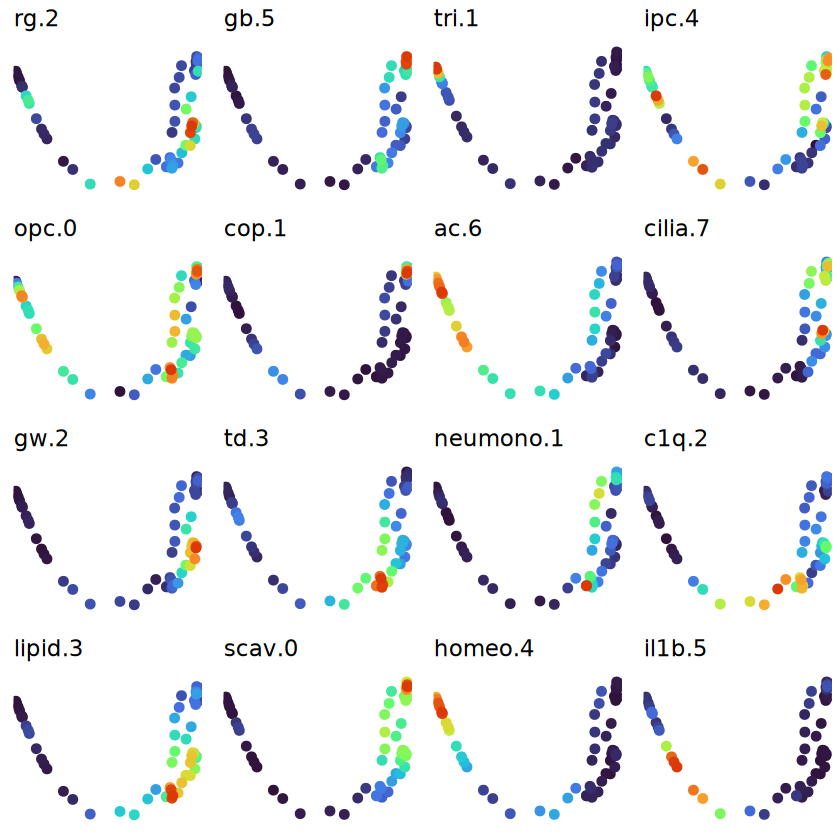

In [4]:
plot.landscape(c('rg.2','gb.5','tri.1','ipc.4','opc.0','cop.1','ac.6','cilia.7','gw.2','td.3',
                 'neumono.1','c1q.2','lipid.3','scav.0','homeo.4','il1b.5'), 
               embedding = 'X_phate',
               enforce.same.color.scale = FALSE, smoothened = TRUE, ncol=4) 

In [43]:
ggsave('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/phate_communities_per_celltype_DMG.pdf', 
      height=10, width=20)

In [45]:
df <- data.frame(pseudotime=data$uns$trajectories$palantir$pseudotime,
                 entropy=apply(py_to_r(data$uns$trajectories$palantir$branch.probs), 1, function(i) -sum(i*log2(i)) %>% ifelse(is.nan(.), 0, .)),
                 py_to_r(data$uns$trajectories$palantir$branch.probs))
df

,pseudotime,entropy,clinical
,<dbl>,<dbl>,<dbl>
projid.1,0.97333111,-1.281371e-15,1
projid.10,0.81744219,-2.883084e-15,1
projid.100,0.83368690,-1.601713e-15,1
projid.101,0.79633110,-2.242399e-15,1
projid.102,0.80159411,-1.922056e-15,1
projid.11,0.90194238,-1.281371e-15,1
projid.12,0.04962191,-8.649252e-15,1
projid.13,0.14601147,-4.164454e-15,1
projid.14,0.14832134,-4.805140e-15,1


In [48]:
library(viridis)  
library(RColorBrewer)
# Generate a color vector from colorRamp2
colors <- circlize::colorRamp2(
  seq(0, 1, length.out = 7), 
  rev(colorRampPalette(brewer.pal(11, "Spectral"))(7))
)(seq(0, 1, length.out = 7))  # Map values to actual colors

In [49]:
color_pseudotime <- colorRampPalette(colors)
color_pseudotime

function (n) 
{
    x <- ramp(seq.int(0, 1, length.out = n))
    if (ncol(x) == 4L) 
        rgb(x[, 1L], x[, 2L], x[, 3L], x[, 4L], maxColorValue = 255)
    else rgb(x[, 1L], x[, 2L], x[, 3L], maxColorValue = 255)
}
<bytecode: 0x555ef5ba9ca8>
<environment: 0x555ef7f87ce8>

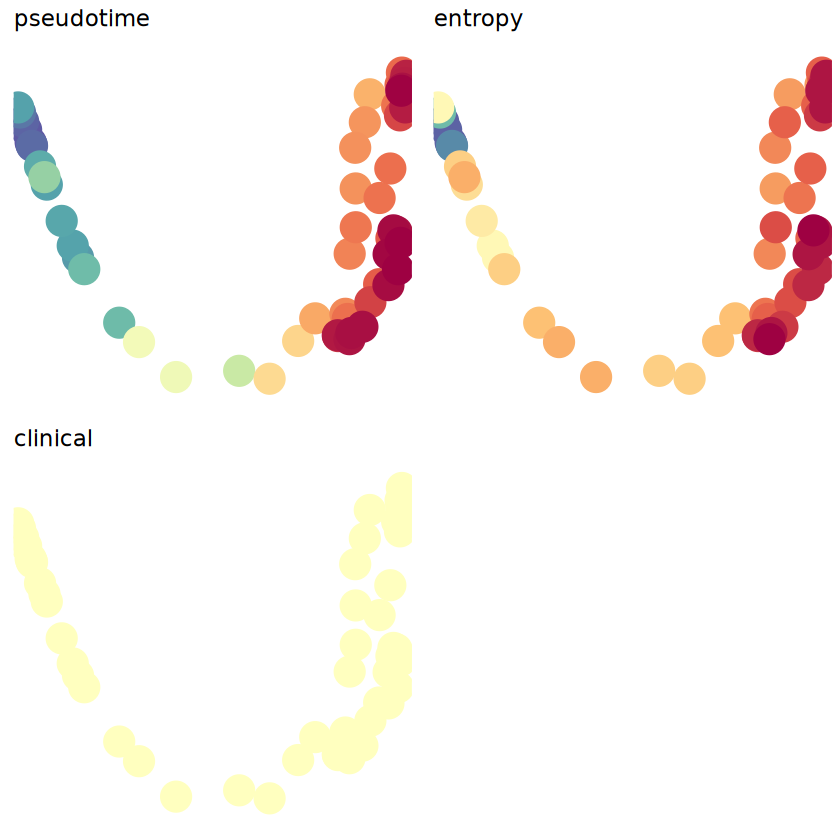

In [50]:
plot.landscape(df, ncol=2, smoothened = F, 
               cols=color_pseudotime, 
               embedding = 'X_phate',
               legend.position = c(3,3), enforce.same.color.scale = F, size=8)

In [51]:
ggsave('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/phate_communities_pseudotime_DMG.pdf', 
      height=5, width=10)

In [3]:
# Local similarities of participants based on cellular environments
data$obsp <- list()
for(e in c("X_phate","X_umap","X_tsne")) 
  data$obsp[[paste0("similarity_", e)]] <- embedding.similarity(data$obsm[[e]], knn = 5)

In [4]:
library(dendextend)
communities   <- data$uns$communities
membership    <- split(data$var_names, data$var$community)
# dynamics      <- communities$similarities$dynamics %>% `dimnames<-`(list(data$var_names, communities$dynamics.colnames))
# corr          <- communities$similarities$correlation %>% `dimnames<-`(list(data$var_names, data$var_names))
# dyn.adjacency <- communities$similarities$dynamics.adjacency %>% `dimnames<-`(list(data$var_names, data$var_names))


---------------------
Welcome to dendextend version 1.17.1
Type citation('dendextend') for how to cite the package.

Type browseVignettes(package = 'dendextend') for the package vignette.
The github page is: https://github.com/talgalili/dendextend/

Suggestions and bug-reports can be submitted at: https://github.com/talgalili/dendextend/issues
You may ask questions at stackoverflow, use the r and dendextend tags: 
	 https://stackoverflow.com/questions/tagged/dendextend

	To suppress this message use:  suppressPackageStartupMessages(library(dendextend))
---------------------



Attaching package: ‘dendextend’


The following object is masked from ‘package:stats’:

    cutree




In [7]:
# here had to change data$var_names for rownames(communities$dynamics.mtx) since order in data$var_namesis not the same!!!

# BE CAREFUL!!!!!
# Matrices were added to the anndata but we did not change the order to match the varn_names!!!

cell_order <- c("ac.6", "c1q.2", "cilia.7", "cop.1", "gb.5", "gw.2", "homeo.4", "il1b.5", "ipc.4", "lipid.3", "neumono.1", "opc.0", "rg.2", "scav.0", "td.3", "tri.1")

dynamics      <- communities$similarities$dynamics %>% `dimnames<-`(list(cell_order, communities$dynamics.colnames))
corr          <- communities$similarities$correlation %>% `dimnames<-`(list(cell_order, cell_order))
dyn.adjacency <- communities$similarities$dynamics.adjacency %>% `dimnames<-`(list(cell_order, cell_order))

In [8]:
# States to annotate
mark.states <- c('rg.2','gb.5','tri.1','ipc.4','opc.0','cop.1','ac.6','cilia.7','gw.2','td.3',
                 'neumono.1','c1q.2','lipid.3','scav.0','homeo.4','il1b.5')

hm.comms <- data$var %>% split(., as.character(.$community)) %>% 
  lapply(., function(inner) {
    
    if(any(!is.na(inner$sub.community))) 
      lst <- split(rownames(inner), as.character(inner$sub.community))
    else
      lst <- list(rownames(inner))
    
    lapply(lst, function(states) {
      mtx  <- dyn.adjacency[states,states] + corr[states,states]
      dend <- dendsort::dendsort(hclust(dist(mtx))) %>% as.dendrogram() %>% set("labels_to_character")
      
      prepare(Heatmap(dynamics[states,],
                      column_split =  factor(gsub("_.*", "", colnames(dynamics)), levels=c("clinical")),
                      cluster_rows = dend, 
                      cluster_row_slices = F,
                      cluster_columns = F,
                      show_column_names = F,
                      show_row_names = T,
                      show_row_dend = T,
                      row_dend_width = unit(10,"pt"),
                      col = circlize::colorRamp2(seq(-4,4,length.out=21), 
                                                 colorRampPalette(c("darkorchid4","white","#E65100"))(21)),
                      column_title = NULL,
                      row_names_side = "left",
                      column_gap = unit(1, "pt"),
                      right_annotation = rowAnnotation(states = anno_mark(which(rownames(mtx) %in% mark.states), intersect(rownames(mtx), mark.states)))))
      
    }) %>% unlist(., recursive=FALSE)
  })  %>% unlist(., recursive=FALSE)

In [9]:
# Create annotations of traits and pseudotime
df <- data$uns$trajectories$palantir$dynamics$pred.vals %>% py_to_r(.) %>% 
  mutate(col=paste(trajectory, x, sep = "_"))
df

,x,fit,se.fit,fit_sd,se.fit_sd,feature,trajectory,col
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
0,0.00000000,0.9517585,0.06476212,NA,NA,ac.6,clinical,clinical_0
1,0.02040816,0.9307235,0.04908195,NA,NA,ac.6,clinical,clinical_0.0204081632653061
2,0.04081633,0.9103370,0.04334876,NA,NA,ac.6,clinical,clinical_0.0408163265306122
3,0.06122449,0.8915655,0.04503717,NA,NA,ac.6,clinical,clinical_0.0612244897959184
4,0.08163265,0.8753682,0.04684133,NA,NA,ac.6,clinical,clinical_0.0816326530612245
5,0.10204082,0.8625342,0.04591963,NA,NA,ac.6,clinical,clinical_0.102040816326531
6,0.12244898,0.8537430,0.04307629,NA,NA,ac.6,clinical,clinical_0.122448979591837
7,0.14285714,0.8496614,0.04019744,NA,NA,ac.6,clinical,clinical_0.142857142857143
8,0.16326531,0.8506172,0.03948689,NA,NA,ac.6,clinical,clinical_0.163265306122449


In [10]:
state.order <- do.call(rbind, lapply(hm.comms, function(hm) data.frame(comm = hm@name, state=rownames(hm@matrix)[row_order(hm)])))
state.order

,comm,state
,<chr>,<chr>
C1.C1.1.1,matrix_1,ac.6
C1.C1.1.2,matrix_1,homeo.4
C1.C1.1.3,matrix_1,il1b.5
C1.C1.2.1,matrix_2,ipc.4
C1.C1.2.2,matrix_2,tri.1
C2.C2.1.1,matrix_3,rg.2
C2.C2.1.2,matrix_3,c1q.2
C2.C2.1.3,matrix_3,opc.0
C2.C2.2.1,matrix_4,cilia.7


In [11]:
dyn.adjacency <- dyn.adjacency[state.order$state, state.order$state]
corr <- corr[state.order$state, state.order$state]

marks <- sapply(mark.states, function(s) which(rownames(dyn.adjacency) == s))
matrices <- list(dyn.adjacency, corr)
# colors   <- list(circlize::colorRamp2(seq(0,1,length.out=21), colorRampPalette(c("white","salmon","red","firebrick4"))(21)),
#                  circlize::colorRamp2(seq(-1,1,length.out=21), green2purple.less.white(21)))

In [12]:
library(viridis)  
library(RColorBrewer)
colors <- list(
  circlize::colorRamp2(seq(0, 1, length.out = 21), colorRampPalette(brewer.pal(11, "BuPu"))(21)),
    circlize::colorRamp2(seq(-1, 1, length.out = 21), rev(colorRampPalette(brewer.pal(11, "RdBu"))(21)))
)

Loading required package: viridisLite

Warning message in brewer.pal(11, "BuPu"):
“n too large, allowed maximum for palette BuPu is 9
Returning the palette you asked for with that many colors
”


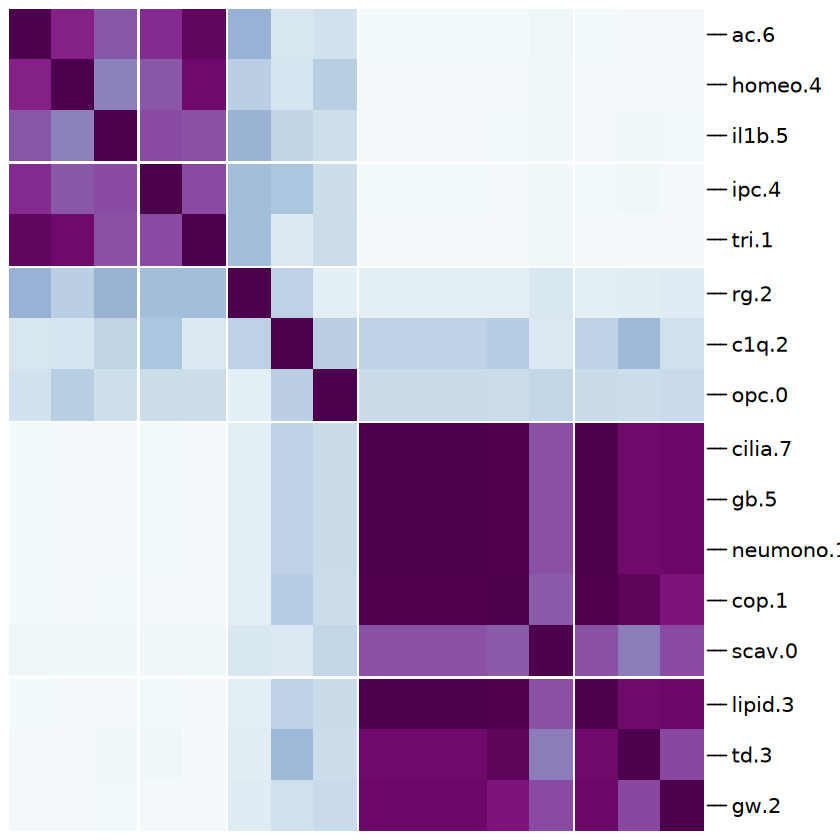

In [13]:
 Heatmap(
    matrices[[1]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[1]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

In [24]:
# Open a PDF device
pdf("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/multicellular_comunities_dynamics_similarity_more_communities_v2.pdf", width = 7.5, height = 7) # Adjust width and height as needed

Heatmap(
    matrices[[1]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[1]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

# Close the PDF device
dev.off()

png 
  2

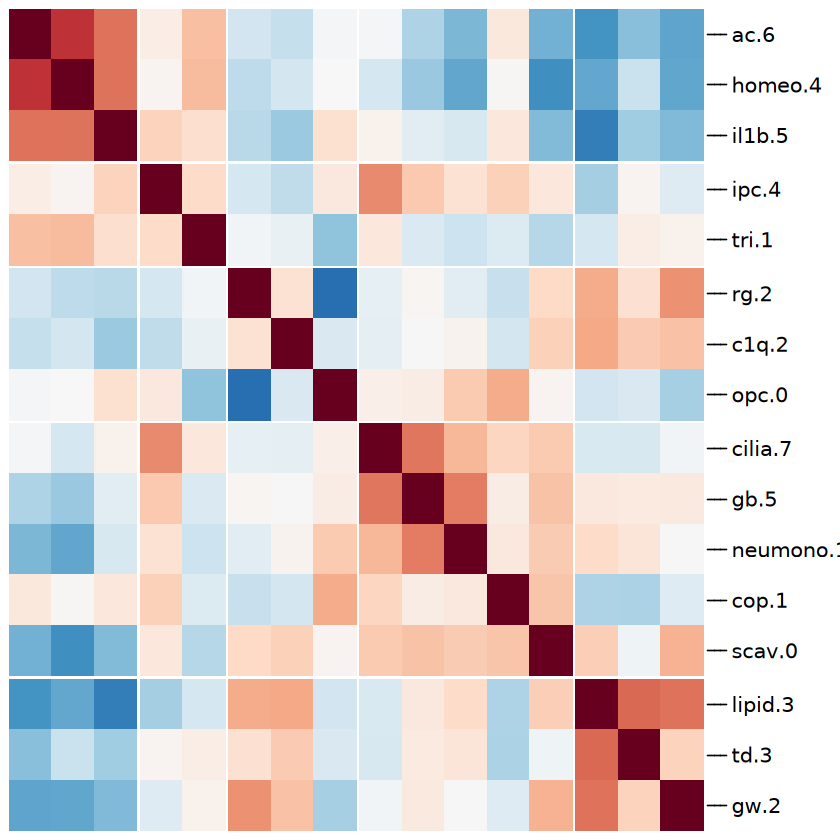

In [14]:
 Heatmap(
    matrices[[2]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[2]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

In [15]:
# Open a PDF device
pdf("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/multicellular_comunities_spearman_correlation_more_communities_v2.pdf", width = 7.5, height = 7) # Adjust width and height as needed

Heatmap(
    matrices[[2]],
    row_split = state.order$comm,
    column_split = state.order$comm,
    cluster_rows = F, 
    cluster_columns = F,
    col = colors[[2]],
    # cell_fun = function(j, i, x, y, w, h, col) {
    #   if(i==j) grid.rect(x,y,w,h, gp = gpar(fill="black", col=NA))
    # },
    column_title = NULL,
    row_title = NULL,
    show_heatmap_legend = F,
    show_row_names = F, 
    show_column_names = F,
    row_gap = unit(2, "pt"),
    column_gap = unit(2, "pt"),
    right_annotation = rowAnnotation(states = anno_mark(marks, names(marks)))
  ) %>% draw()

# Close the PDF device
dev.off()

png 
  2

In [29]:
hm.comms <- data$var %>% split(., as.character(.$community)) %>% 
  lapply(., function(inner) {
    
    if(any(!is.na(inner$sub.community))) 
      lst <- split(rownames(inner), as.character(inner$sub.community))
    else
      lst <- list(rownames(inner))
    
    lapply(lst, function(states) {
      mtx  <- dyn.adjacency[states,states] + corr[states,states]
      dend <- dendsort::dendsort(hclust(dist(mtx))) %>% as.dendrogram() %>% set("labels_to_character")
      
      prepare(Heatmap(dynamics[states,],
                      column_split =  factor(gsub("_.*", "", colnames(dynamics)), levels=c("clinical")),
                      cluster_rows = dend, 
                      cluster_row_slices = F,
                      cluster_columns = F,
                      show_column_names = F,
                      show_row_names = T,
                      show_row_dend = T,
                      row_dend_width = unit(10,"pt"),
                      col = circlize::colorRamp2(seq(-4,4,length.out=21), 
                                                 colorRampPalette(c("#dbac48", "white", "#4271a6"))(21)),
                      column_title = NULL,
                      row_names_side = "left",
                      column_gap = unit(1, "pt"),
                      right_annotation = rowAnnotation(states = anno_mark(which(rownames(mtx) %in% mark.states), intersect(rownames(mtx), mark.states)))))
      
    }) %>% unlist(., recursive=FALSE)
  })  %>% unlist(., recursive=FALSE)

$C1.C1.1


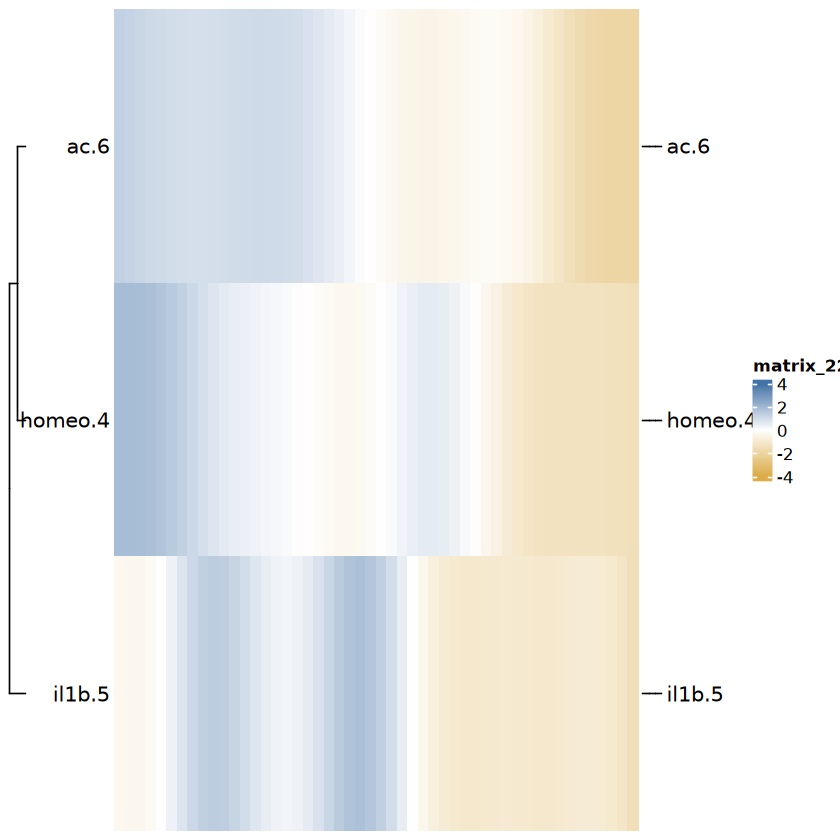

In [30]:
hm.comms[1]

$C1.C1.2


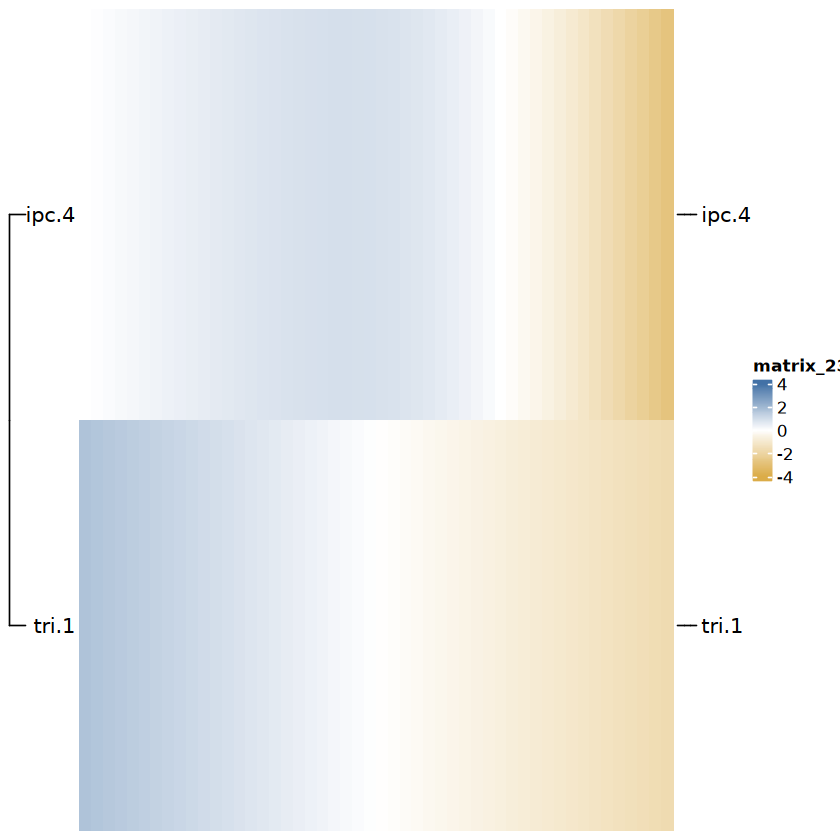

In [31]:
hm.comms[2]

$C2.C2.1


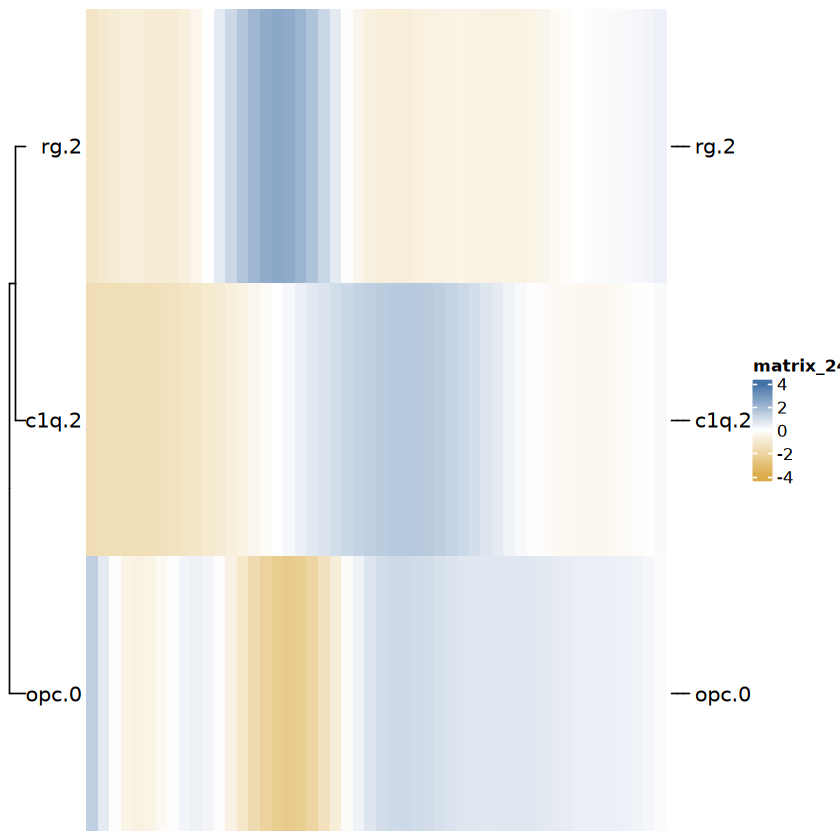

In [32]:
hm.comms[3]

$C2.C2.2


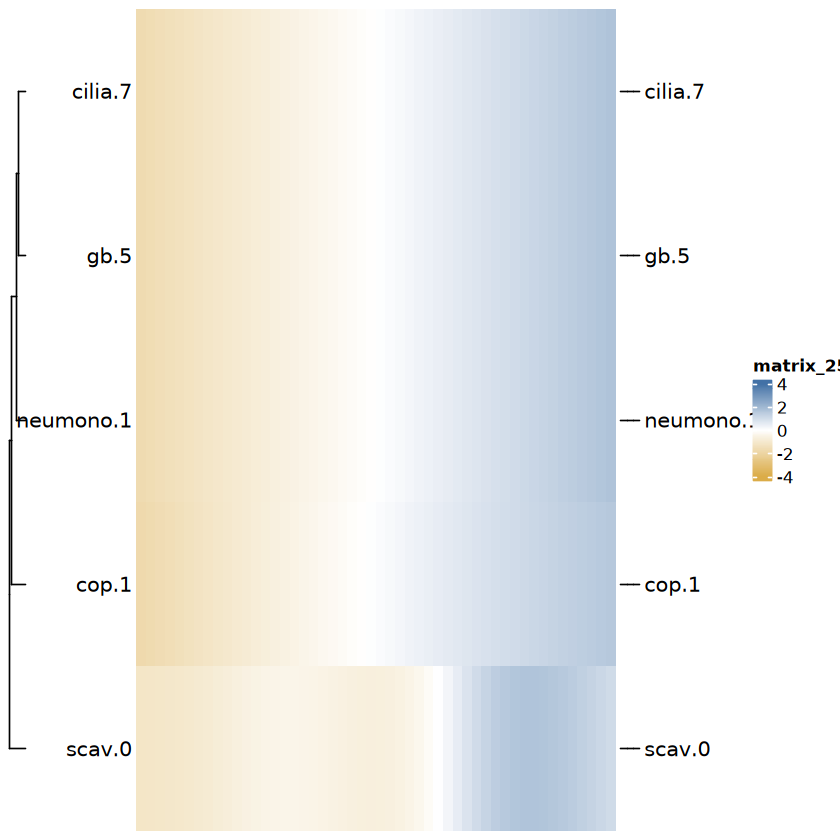

In [33]:
hm.comms[4]

$C2.C2.3


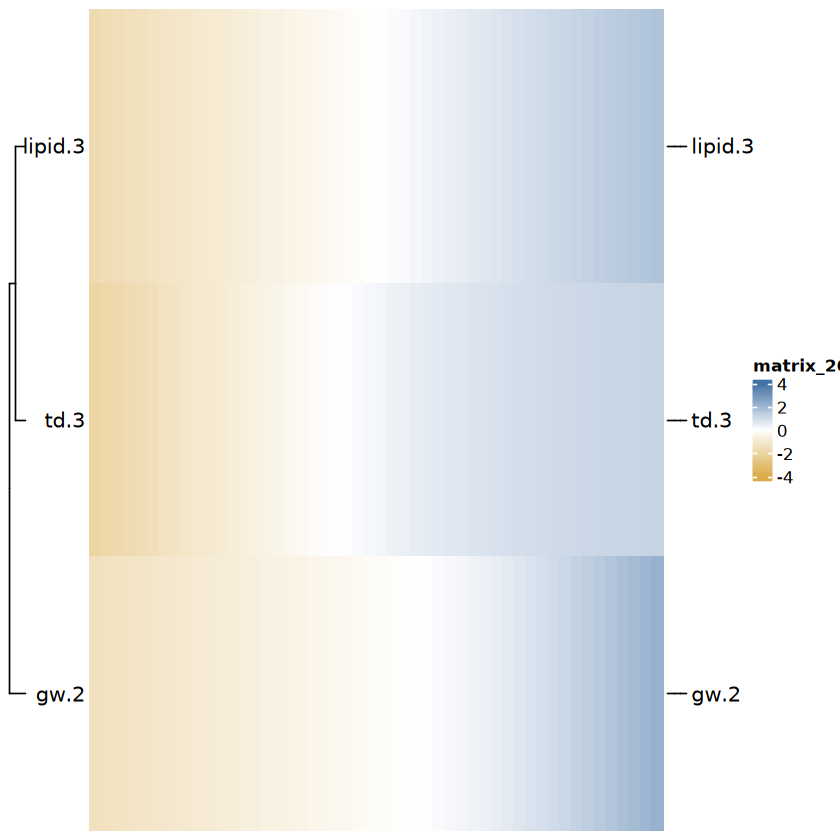

In [34]:
hm.comms[5]

In [35]:
# Iterate through each subplot in the list
for (i in seq_along(hm.comms)) {
  # Construct a file name for each subplot
  pdf_file <- file.path('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/', 
                        paste0("heatmap_subplot_", i, "_v2.pdf"))
  
  # Open a PDF device
  pdf(pdf_file, width = 10, height = 8) # Adjust the size as needed
  
  # Draw the heatmap
  draw(hm.comms[[i]])
  
  # Close the PDF device
  dev.off()
}

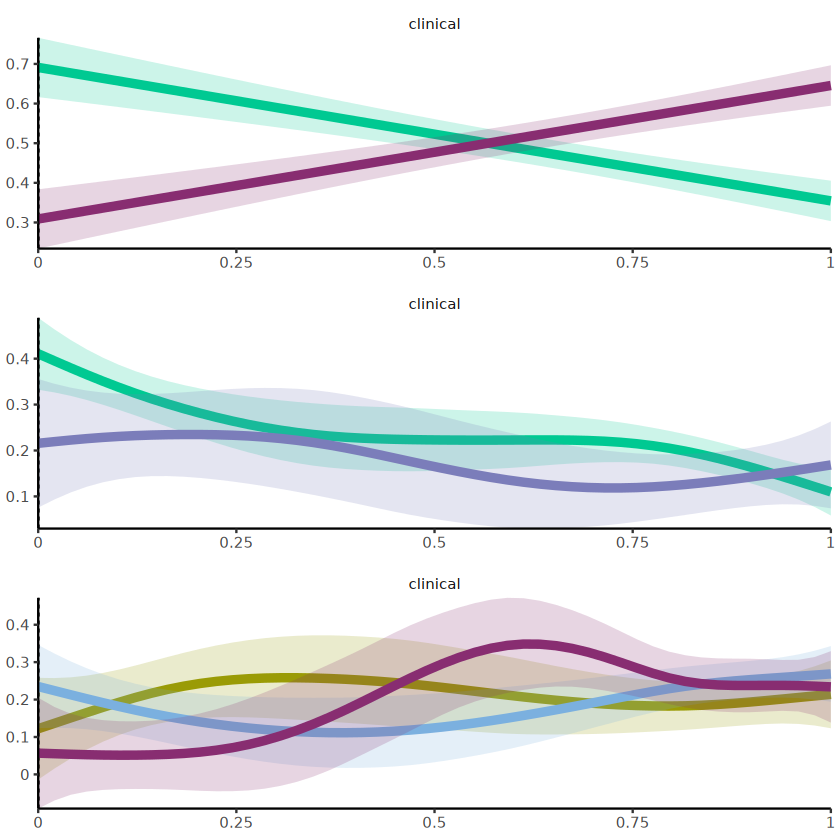

In [47]:
plot_grid(
          plot.dynamics(c("C1.1","C1.2"), dynamics = data$uns$communities$dynamics, cols = comm.cols, include.points = FALSE,legend.position = c(3,3), overlap.pseudotime = 0) + labs(x=NULL, y=NULL),
          plot.dynamics(c("C2.1","C2.2", 'C2.3'), dynamics = data$uns$communities$dynamics, cols = comm.cols, include.points = FALSE,legend.position = c(3,3), overlap.pseudotime =0) + labs(x=NULL, y=NULL),
          ncol=1)

In [39]:
state.dynamics.sets <- list(
    list(ac.6="#caa4ab", homeo.4="#26a9e0", il1b.5 = "#343682"),
    list(ipc.4='#fdc955', tri.1 = "#b26671" ),
    list(rg.2="#74150f", opc.0="#c13910", c1q.2="#165884"),
    list(neumono.1="#00a69c", gb.5="#474747", cop.1='#f4e5e1', cilia.7='#9a9b06', scav.0="#95bbcd"),
    list(lipid.3="#7b7dba", gw.2 = "#5c2454", td.3='#ba7db3')
)

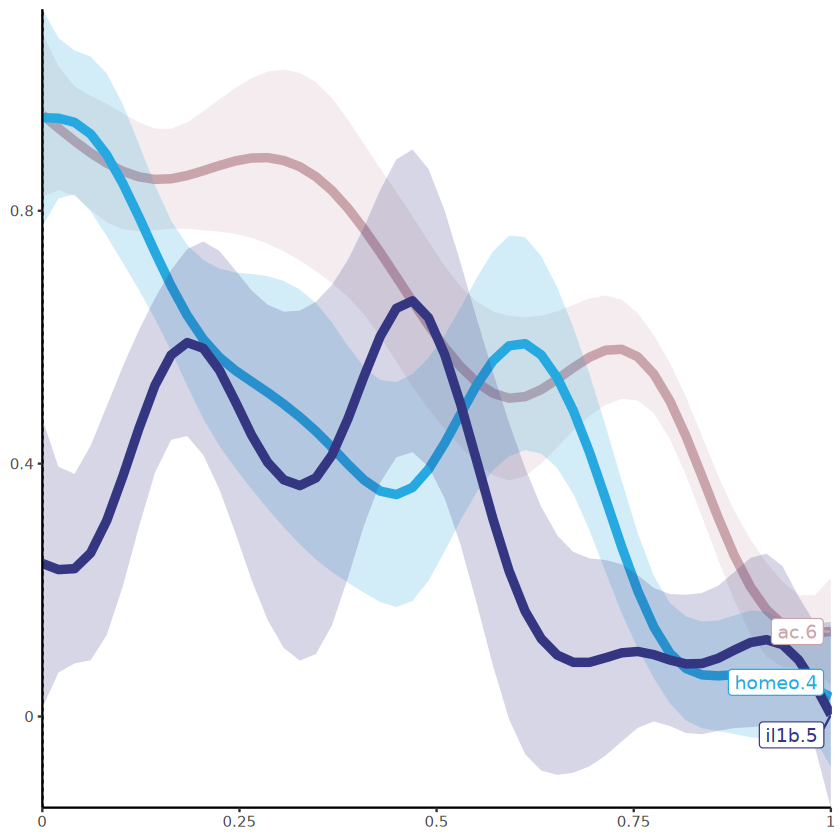

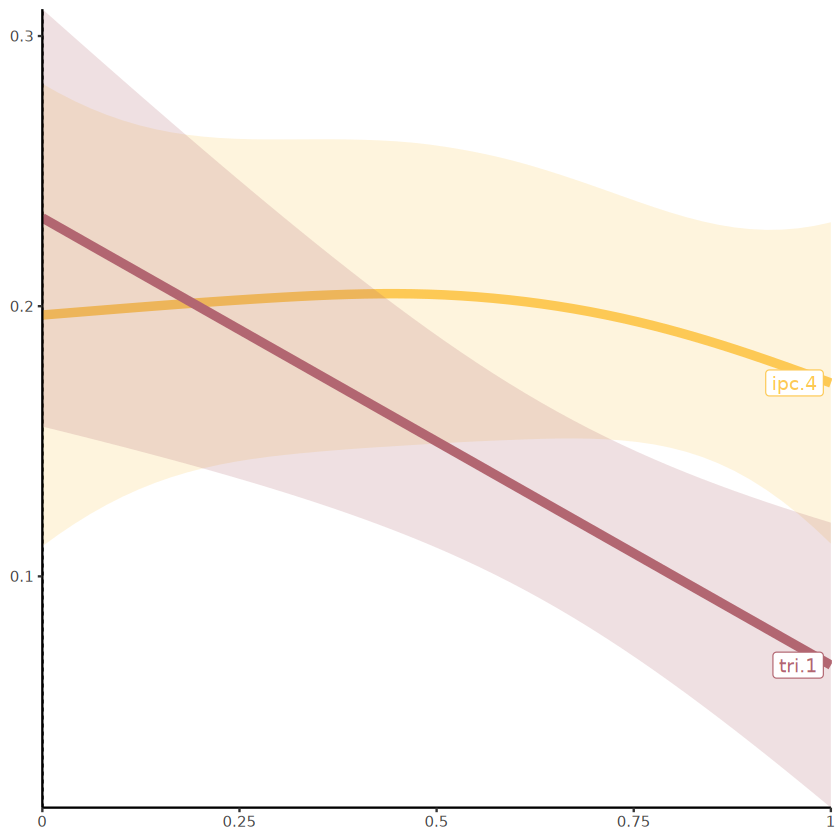

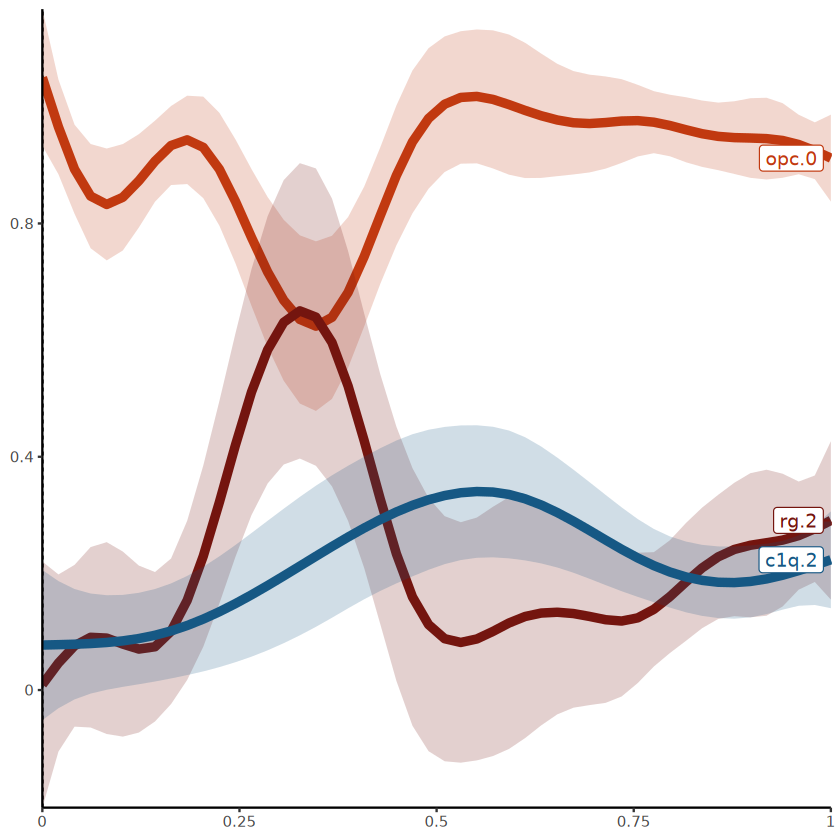

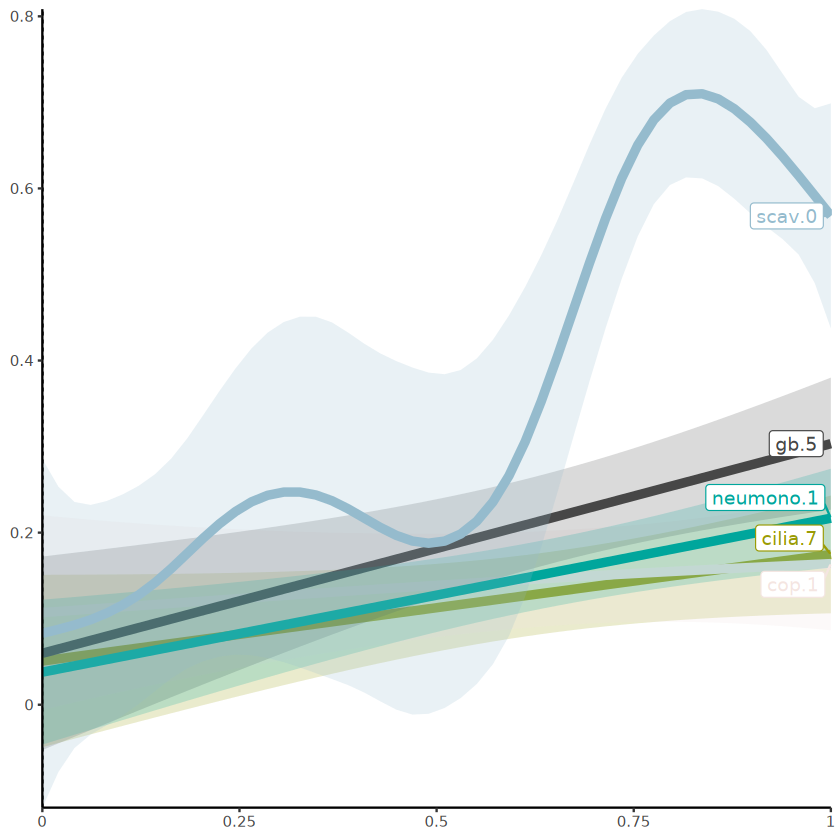

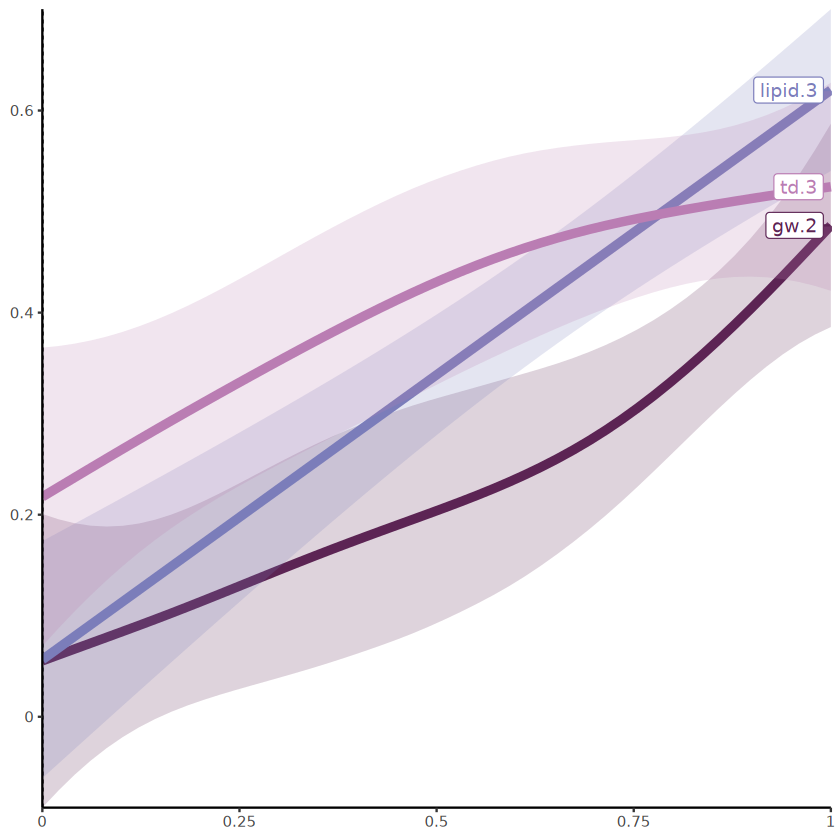

In [40]:
for(states in state.dynamics.sets) {
  print(plot.dynamics(names(states), cols = states, overlap.pseudotime=0, label=TRUE) + 
    theme(strip.text = element_blank(), 
          legend.position="none", 
          axis.line = element_line(), 
          axis.text.y = element_text()) + 
    labs(x=NULL, y=NULL, title=NULL))
}

In [41]:
# Loop through the states and save each plot to the PDF
for (states in state.dynamics.sets) {
  plot.dynamics(names(states), cols = states, overlap.pseudotime = 0, label = TRUE) + 
    theme(strip.text = element_blank(), 
          legend.position = "none", 
          axis.line = element_line(), 
          axis.text.y = element_text()) + 
    labs(x = NULL, y = NULL, title = NULL)
  
  ggsave(paste0('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_', states, '_FINAL_v2.pdf'), 
      height=5, width=5)
}

Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_", :
“`filename` must have length 1, not 3.
! Only the first, /projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_#caa4ab_FINAL_v2.pdf, will be
  used.”
Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_", :
“`filename` must have length 1, not 2.
! Only the first, /projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_#fdc955_FINAL_v2.pdf, will be
  used.”
Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_", :
“`filename` must have length 1, not 3.
! Only the first, /projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_per_cell_type_#74150f_FINAL_v2.pdf, will be
  used.”
Warning message in ggsave(paste0("/projects/0/einf2548/cruiz/dmg/data/bey

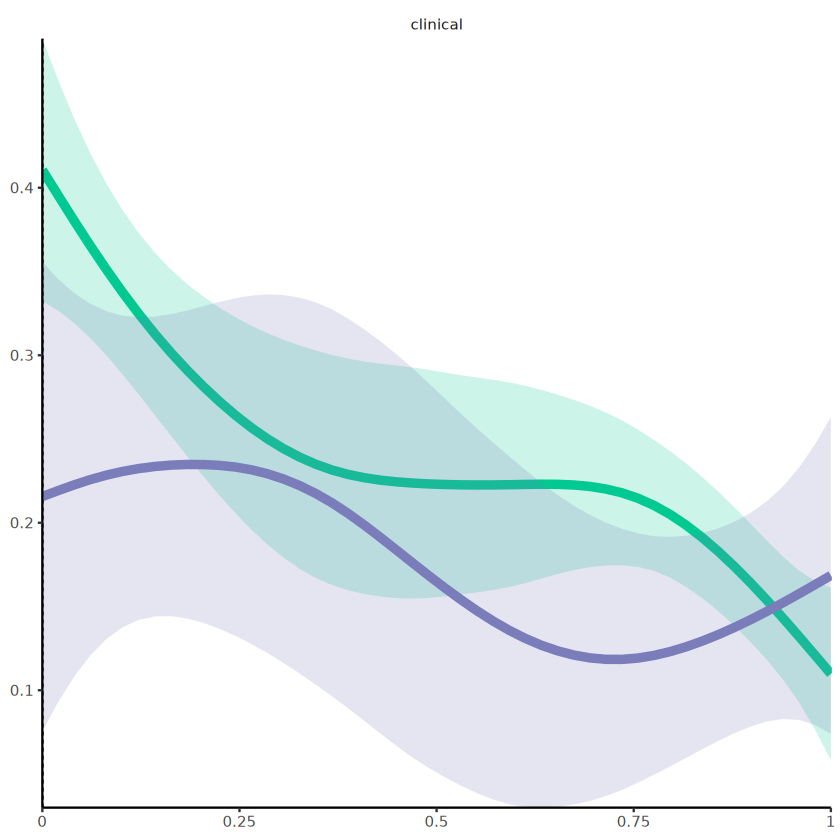

In [53]:
          plot.dynamics(c("C1.1","C1.2"), dynamics = data$uns$communities$dynamics, cols = comm.cols, include.points = FALSE,legend.position = c(3,3), overlap.pseudotime = 0) + labs(x=NULL, y=NULL)
ggsave(paste0('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_subcommunity_1.pdf'), 
      height=5, width=5)

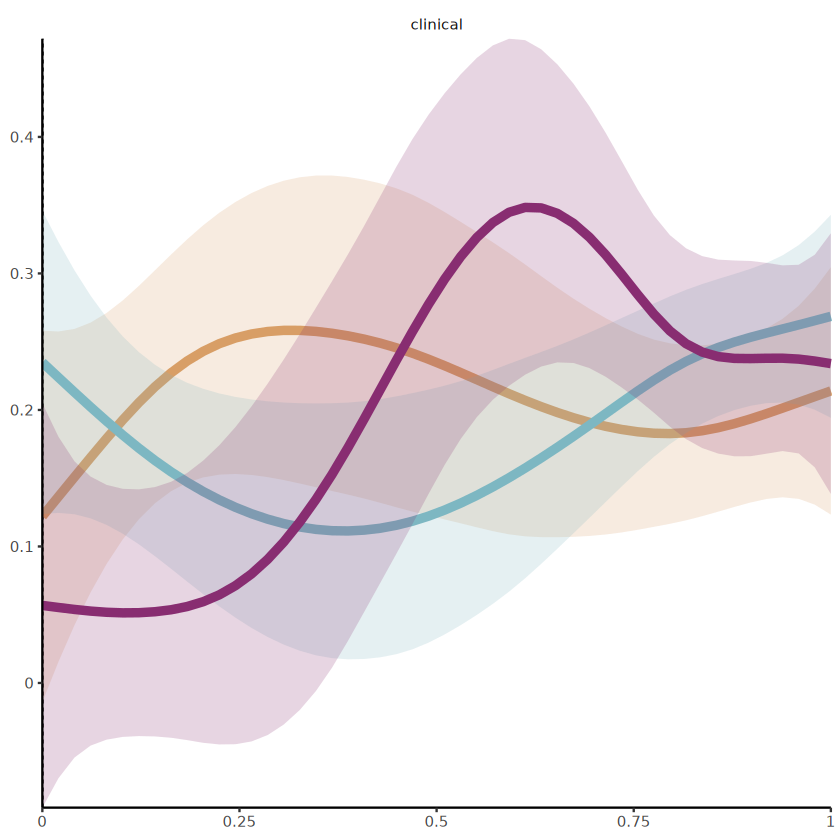

In [54]:
 plot.dynamics(c("C2.1","C2.2", 'C2.3'), dynamics = data$uns$communities$dynamics, cols = comm.cols, include.points = FALSE,legend.position = c(3,3), overlap.pseudotime =0) + labs(x=NULL, y=NULL)
ggsave(paste0('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_subcommunity_2.pdf'), 
      height=5, width=5)

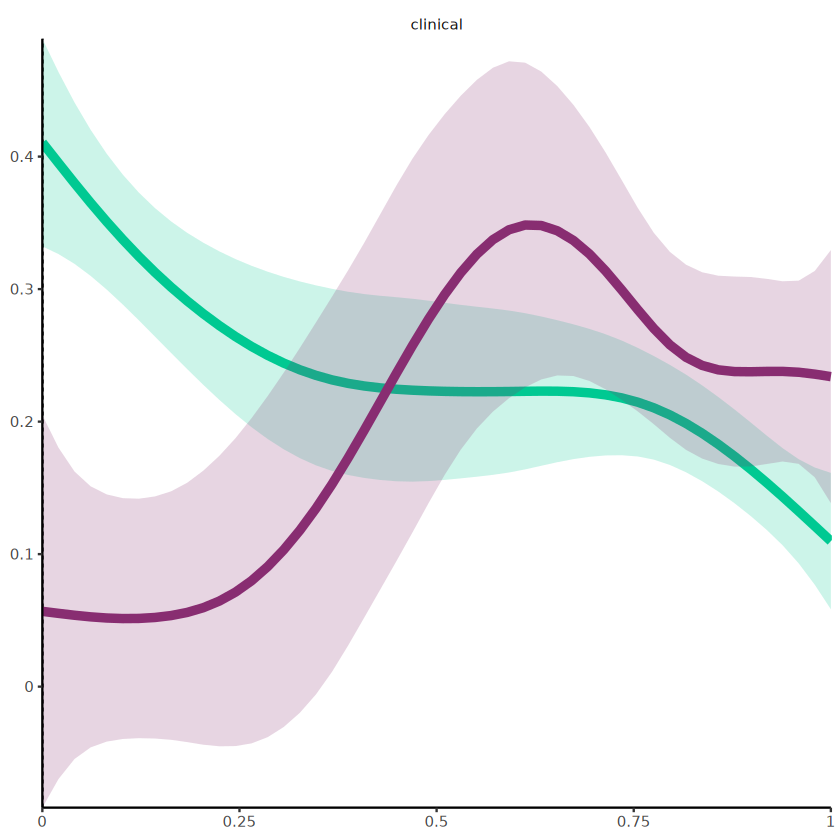

In [20]:
          plot.dynamics(c("C1.1","C2.3"), 
                        dynamics = data$uns$communities$dynamics, 
                        cols = comm.cols, include.points = FALSE,
                        legend.position = c(3,3), overlap.pseudotime = 0) + 
labs(x=NULL, y=NULL)

ggsave(paste0('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_subcommunity_ttx_dynamic.pdf'),  height=5, width=5)

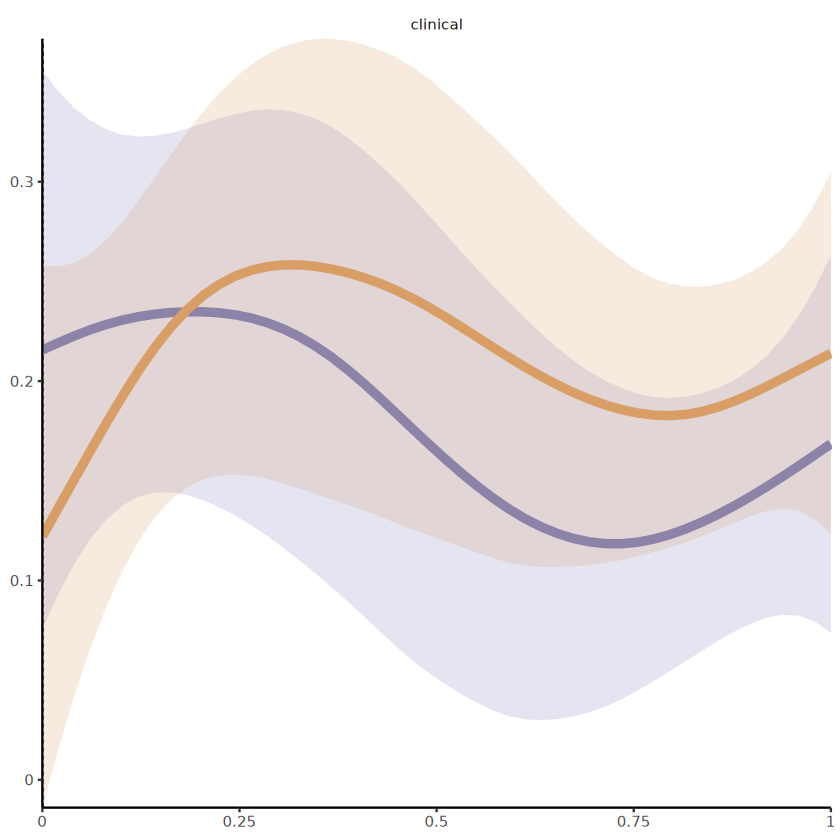

In [21]:
 plot.dynamics(c("C1.2","C2.1"), dynamics = data$uns$communities$dynamics, cols = comm.cols, include.points = FALSE,legend.position = c(3,3), overlap.pseudotime =0) + labs(x=NULL, y=NULL)
ggsave(paste0('/projects/0/einf2548/cruiz/dmg/data/beyond/figures/dynamics_scatter_plot_subcommunity_ttx_stable.pdf'), 
      height=5, width=5)

### Python kernel

In [1]:
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

H5AD = Path("/projects/0/einf2548/cruiz/dmg/data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad")
OUTDIR = Path("c1c2_outputs"); OUTDIR.mkdir(exist_ok=True, parents=True)

adata = ad.read_h5ad(H5AD)
obs = adata.obs.copy()
obs

/home/cruiz2/miniconda3/envs/cellcharter/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


,Study,PatientID,PatientIDdetail,Preservation_method,Diagnosis,Tumor_type,Tumor_subtype,Location,Source,Clinical_status,Timepoint,Paired_sample,Multisector,Gender,Age_years,Dexamethasone_prior_surgery,clusters
projid.1,Ruiz2023,T18-90532,BT042_PD,Cryo,DMG Pons,DMG H3 K27-altered,H3.1 K27-mutant,Pons,Autopsy,Recurrence,NaN,N,Y,F,NaN,No,2
projid.10,Ruiz2023,GNG,GNG_region_6,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Autopsy,Recurrence,NaN,N,Y,M,NaN,Yes,1
projid.100,Sussman2024,C2751264,HTAN_pHGG_6761_Reg2_snRNA,NaN,NaN,DMG H3 K27-altered,NaN,NaN,NaN,Primary,Initial CNS Tumor,NaN,NaN,NaN,NaN,NaN,5
projid.101,Sussman2024,C2751264,HTAN_pHGG_7622_Reg1_snRNA,NaN,NaN,DMG H3 K27-altered,NaN,NaN,NaN,Recurrence,Progressive (Autopsy),NaN,NaN,NaN,NaN,NaN,6
projid.102,Sussman2024,C2751264,HTAN_pHGG_7622_Reg2_snRNA,NaN,NaN,DMG H3 K27-altered,NaN,NaN,NaN,Recurrence,Progressive (Autopsy),NaN,NaN,NaN,NaN,NaN,6
projid.11,Ruiz2023,T19-90627,T19-90627_466AAL,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NaN,N,N,F,NaN,Yes,4
projid.12,Ruiz2023,T19-90673,T19-90673_577AAL_section_1,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NaN,N,N,F,NaN,No,3
projid.13,Ruiz2023,T19-90673,T19-90673_577AAL_section_2,Snap-frozen,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NaN,N,N,F,NaN,No,3
projid.14,Ruiz2023,T19-91014,T19-91014_635AAM_core,Cryo,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NaN,N,Y,M,NaN,Yes,7
projid.15,Ruiz2023,T19-91014,T19-91014_635AAM_edge,Cryo,DMG Pons,DMG H3 K27-altered,H3.3 K27-mutant,Pons,Biopsy,Primary,NaN,N,Y,M,NaN,Yes,7


In [3]:
 adata.uns['communities']

{'dynamics': {'evaluations':      comparison      Deviance          F        Pr..F.  i feature trajectory
  2          null -7.545732e-01  42.747118  2.148710e-08  1      C1   clinical
  21   unweighted  1.665335e-15        NaN           NaN  1      C1   clinical
  22         null -7.545732e-01  42.747118  2.148710e-08  1      C2   clinical
  211  unweighted  1.665335e-15        NaN           NaN  1      C2   clinical
  23         null -4.143241e-01  13.171645  2.061719e-07  1    C1.1   clinical
  212  unweighted  1.054712e-15   9.253525  2.117064e-13  1    C1.1   clinical
  24         null -1.652023e-01   1.692107  1.774792e-01  1    C1.2   clinical
  213  unweighted  5.107026e-15        NaN           NaN  1    C1.2   clinical
  25         null -1.148340e-01   1.231486  3.086300e-01  1    C2.1   clinical
  214  unweighted  2.886580e-15  15.255815  1.065390e-13  1    C2.1   clinical
  26         null -1.783400e-01   2.880983  3.881211e-02  1    C2.2   clinical
  215  unweighted  1.2212

In [7]:
from typing import Optional, Tuple


COMMUNITIES_OF_INTEREST = ["C1", "C2"]
COLORS = {"C1": "#00062f", "C2": "#d8c31b"}

SAMPLE_COL_CANDIDATES   = ["SampleID","sample","sample_id","Sample","sampleid","donor","Donor"]
CLINICAL_COL_CANDIDATES = ["Clinical_status","clinical_status","ClinicalStatus","Tumor_type","status","tumor_status"]

# ---------------- helpers ----------------
def find_sample_col(obs: pd.DataFrame) -> Optional[str]:
    for c in SAMPLE_COL_CANDIDATES:
        if c in obs.columns:
            return c
    return None

def find_clinical_col(obs: pd.DataFrame) -> Optional[str]:
    for c in CLINICAL_COL_CANDIDATES:
        if c in obs.columns:
            return c
    return None

def get_feature_list_from_dynamics(uns_comm: dict) -> list[str]:
    feats = []
    if isinstance(uns_comm, dict) and "dynamics" in uns_comm and isinstance(uns_comm["dynamics"], dict):
        evals = uns_comm["dynamics"].get("evaluations", None)
        if isinstance(evals, pd.DataFrame) and "feature" in evals.columns:
            feats = sorted(evals["feature"].astype(str).unique().tolist())
    return feats

def as_df(x) -> Optional[pd.DataFrame]:
    try:
        df = pd.DataFrame(x)
        return df
    except Exception:
        return None

def score_columns_for_communities(cols: list[str], communities: list[str]) -> int:
    s = 0
    setcols = set(cols)
    for c in communities:
        if c in setcols:
            s += 1
        else:
            # try relaxed matches like 'C1.', 'C1_', 'communities.C1', 'C1_prop'
            for col in setcols:
                if col == c or col.startswith(c + ".") or col.startswith(c + "_") or col.endswith("." + c) or col.endswith("_" + c) or col.endswith("/" + c):
                    s += 1
                    break
    return s

def normalize_columns(df: pd.DataFrame, wanted: list[str]) -> pd.DataFrame:
    """Return a DataFrame with columns exactly named wanted by mapping relaxed matches."""
    out = pd.DataFrame(index=df.index)
    for w in wanted:
        if w in df.columns:
            out[w] = df[w].astype(float)
        else:
            # relaxed search
            hit = None
            for col in df.columns:
                if col == w or col.startswith(w + ".") or col.startswith(w + "_") or col.endswith("." + w) or col.endswith("_" + w) or col.endswith("/" + w):
                    hit = col; break
            out[w] = df[hit].astype(float) if hit is not None else 0.0
    return out

def locate_donor_by_community_matrix(adata: ad.AnnData, features_from_dynamics: list[str]) -> Tuple[pd.DataFrame, str]:
    """
    Try, in order:
      1) adata.obsm candidates
      2) columns in adata.obs
      3) adata.X (if looks like donors×communities and we can name columns)
    Returns (df, source_desc) with df index == adata.obs_names and columns = community names (strings).
    """
    # 1) OBMS
    obsm_candidates = ["Y","fractions","proportions","communities","community_fractions","community_proportions"]
    # also try all obsm keys
    obsm_keys = list(adata.obsm.keys())
    scan_obsm = obsm_candidates + [k for k in obsm_keys if k not in obsm_candidates]

    best_df = None
    best_score = -1
    best_source = None

    for k in scan_obsm:
        arr = adata.obsm.get(k, None)
        if arr is None:
            continue
        df = as_df(arr)
        if df is None or df.shape[0] != adata.n_obs:
            continue
        # try to name columns from dynamics if same width
        if features_from_dynamics and df.shape[1] == len(features_from_dynamics):
            df.columns = features_from_dynamics
        else:
            df.columns = [str(c) for c in df.columns]
        score = score_columns_for_communities(list(df.columns), COMMUNITIES_OF_INTEREST)
        if score > best_score:
            best_df = df.copy()
            best_df.index = adata.obs_names
            best_score = score
            best_source = f"obsm['{k}']"

    if best_df is not None:
        print(f"[INFO] Picked donor×community from {best_source} (shape={best_df.shape}, matched {best_score}/{len(COMMUNITIES_OF_INTEREST)} of {COMMUNITIES_OF_INTEREST})")
        return best_df, best_source

    # 2) OBS columns
    obs_num = adata.obs.select_dtypes(include=[np.number])
    if obs_num.shape[1] > 0:
        score = score_columns_for_communities(list(obs_num.columns), COMMUNITIES_OF_INTEREST)
        if score > 0:
            print(f"[INFO] Using numeric columns in obs (matched {score}/{len(COMMUNITIES_OF_INTEREST)} of {COMMUNITIES_OF_INTEREST})")
            return obs_num.copy(), "obs[numeric columns]"

    # 3) X as last resort (donors×communities)
    Xdf = as_df(adata.X)
    if Xdf is not None and Xdf.shape[0] == adata.n_obs:
        if features_from_dynamics and Xdf.shape[1] == len(features_from_dynamics):
            Xdf.columns = features_from_dynamics
        else:
            Xdf.columns = [f"C{i+1}" for i in range(Xdf.shape[1])]
        Xdf.index = adata.obs_names
        score = score_columns_for_communities(list(Xdf.columns), COMMUNITIES_OF_INTEREST)
        print(f"[WARN] Falling back to adata.X (shape={Xdf.shape}, matched {score}/{len(COMMUNITIES_OF_INTEREST)})")
        return Xdf, "X"

    raise RuntimeError(
        "Could not locate a donor×community matrix in obsm/obs/X. "
        "Please store donor-by-community fractions in adata.obsm (e.g., 'Y' or 'proportions')."
    )

def stacked_per_sample(wide_df: pd.DataFrame, title: str, fname: Path):
    wide = wide_df.fillna(0.0)
    x = np.arange(wide.shape[0]); bottom = np.zeros(wide.shape[0])
    plt.figure(figsize=(max(10, 0.35*wide.shape[0]), 4.6))
    for c in COMMUNITIES_OF_INTEREST:
        plt.bar(x, wide[c].values, bottom=bottom, label=c, color=COLORS.get(c))
        bottom += wide[c].values
    plt.xticks(x, wide.index, rotation=90)
    plt.ylabel("Proportion")
    plt.title(title)
    plt.ylim(0, 1)
    plt.legend(title="Community", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.close()

def stacked_per_sample_grouped_by_status(df: pd.DataFrame, status: pd.Series, title: str, fname: Path):
    order = pd.DataFrame({"SampleID": df.index, "Clinical_status": status.loc[df.index].astype(str)}).sort_values(["Clinical_status","SampleID"])["SampleID"].tolist()
    wide = df.reindex(order).fillna(0.0)
    groups = status.loc[wide.index].astype(str).tolist()
    boundaries = [i for i in range(1, len(groups)) if groups[i] != groups[i-1]]
    x = np.arange(wide.shape[0]); bottom = np.zeros(wide.shape[0])
    plt.figure(figsize=(max(12, 0.42*wide.shape[0]), 5.0))
    for c in COMMUNITIES_OF_INTEREST:
        plt.bar(x, wide[c].values, bottom=bottom, label=c, color=COLORS.get(c))
        bottom += wide[c].values
    for b in boundaries: plt.axvline(b-0.5, linestyle="--", linewidth=1)
    plt.xticks(x, wide.index, rotation=90)
    plt.ylabel("Proportion")
    plt.title(title)
    # group labels
    start = 0
    for bnd in boundaries + [len(groups)]:
        mid = (start + bnd - 1) / 2
        if mid >= 0:
            plt.text(mid, 1.05, groups[start], ha="center", va="bottom", fontsize=10)
        start = bnd
    plt.ylim(0, 1.1)
    plt.legend(title="Community", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.close()

def aggregated_by_status_mean(df: pd.DataFrame, status: pd.Series, title: str, fname: Path):
    agg = df.assign(Clinical_status=status.loc[df.index].astype(str)).groupby("Clinical_status")[COMMUNITIES_OF_INTEREST].mean()
    x = np.arange(agg.shape[0]); bottom = np.zeros(agg.shape[0])
    plt.figure(figsize=(max(5.5, 2.2*agg.shape[0]), 4.2))
    for c in COMMUNITIES_OF_INTEREST:
        plt.bar(x, agg[c].values, bottom=bottom, label=c, color=COLORS.get(c))
        bottom += agg[c].values
    plt.xticks(x, agg.index)
    plt.ylabel("Mean proportion")
    plt.title(title)
    plt.ylim(0, 1)
    plt.legend(title="Community", bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.close()

# ---------------- RUN ----------------
adata = ad.read_h5ad(H5AD)
print("[INFO] obs shape:", adata.obs.shape)
print("[INFO] uns keys:", list(adata.uns.keys()))
print("[INFO] obsm keys:", list(adata.obsm.keys()))
print("[INFO] layers:", list(adata.layers.keys()) if hasattr(adata, "layers") else [])

features = get_feature_list_from_dynamics(adata.uns.get("communities", {}))
print("[INFO] features from dynamics:", features)

# locate donor×community matrix
comm_df, source = locate_donor_by_community_matrix(adata, features)
comm_df.index = adata.obs_names  # donors

# figure out sample label and status (labels only, no weights)
sample_col   = find_sample_col(adata.obs)
clinical_col = find_clinical_col(adata.obs)

sample_ids = (adata.obs_names if sample_col is None else adata.obs[sample_col].astype(str))
status     = (pd.Series("NA", index=adata.obs_names) if clinical_col is None
              else adata.obs[clinical_col].astype(str))

# normalize/align columns to exactly C1 and C2
c12 = normalize_columns(comm_df, COMMUNITIES_OF_INTEREST)

# ---- Variant A: proportions of ALL communities (share of total per donor) ----
sum_all = comm_df.sum(axis=1)
prop_all = c12.divide(sum_all.replace(0, np.nan), axis=0)
prop_all.index = sample_ids.values  # index = "SampleID" for plotting

# ---- Variant B: normalized within C1+C2 per donor ----
sum_c12 = c12.sum(axis=1)
prop_c12 = c12.divide(sum_c12.replace(0, np.nan), axis=0)
prop_c12.index = sample_ids.values

# save tidy CSVs (no counts)
prop_all.assign(Clinical_status=status.values).reset_index(names="SampleID").melt(
    id_vars=["SampleID","Clinical_status"], value_vars=COMMUNITIES_OF_INTEREST,
    var_name="community", value_name="prop_of_ALL"
).to_csv(OUTDIR/"C1C2_prop_of_ALL_per_sample.csv", index=False)

prop_c12.assign(Clinical_status=status.values).reset_index(names="SampleID").melt(
    id_vars=["SampleID","Clinical_status"], value_vars=COMMUNITIES_OF_INTEREST,
    var_name="community", value_name="prop_within_C1C2"
).to_csv(OUTDIR/"C1C2_prop_within_C1C2_per_sample.csv", index=False)

# ---- PLOTS ----
stacked_per_sample(prop_all, "Per-sample C1/C2 (proportion of ALL communities)",
                   OUTDIR/"stacked_C1C2_per_sample_ofALL.png")

stacked_per_sample_grouped_by_status(prop_all, status.rename(index=dict(zip(adata.obs_names, prop_all.index))),
                                     "Per-sample C1/C2 grouped by Clinical_status (of ALL communities)",
                                     OUTDIR/"stacked_C1C2_per_sample_grouped_by_status_ofALL.png")

aggregated_by_status_mean(prop_all, status.rename(index=dict(zip(adata.obs_names, prop_all.index))),
                          "Aggregated by Clinical_status (mean; of ALL communities)",
                          OUTDIR/"stacked_C1C2_agg_by_status_ofALL.png")

stacked_per_sample(prop_c12, "Per-sample C1/C2 (normalized within C1+C2)",
                   OUTDIR/"stacked_C1C2_per_sample_withinC12.png")

stacked_per_sample_grouped_by_status(prop_c12, status.rename(index=dict(zip(adata.obs_names, prop_c12.index))),
                                     "Per-sample C1/C2 grouped by Clinical_status (within C1+C2)",
                                     OUTDIR/"stacked_C1C2_per_sample_grouped_by_status_withinC12.png")

aggregated_by_status_mean(prop_c12, status.rename(index=dict(zip(adata.obs_names, prop_c12.index))),
                          "Aggregated by Clinical_status (mean; within C1+C2)",
                          OUTDIR/"stacked_C1C2_agg_by_status_withinC12.png")

print("Done. Source for donor×community =", source)
print("Outputs in:", OUTDIR.resolve())

[INFO] obs shape: (57, 17)
[INFO] uns keys: ['cell.types', 'communities', 'leiden', 'leiden_R', 'neighbors', 'ss.cor', 'trajectories', 'tsne', 'umap']
[INFO] obsm keys: ['X_all_3d_phate', 'X_phate', 'X_tsne', 'X_umap', 'communities', 'sub.communities']
[INFO] layers: ['counts', 'sqrt.prev']
[INFO] features from dynamics: ['C1', 'C1.1', 'C1.2', 'C2', 'C2.1', 'C2.2', 'C2.3']
[INFO] Picked donor×community from obsm['communities'] (shape=(57, 2), matched 2/2 of ['C1', 'C2'])
Done. Source for donor×community = obsm['communities']
Outputs in: /gpfs/work2/0/einf2548/cruiz/dmg/notebooks/c1c2_outputs


In [8]:
from scipy.stats import mannwhitneyu

COMMUNITIES = ["C1", "C2"]
COLORS = {"C1": "#00062f", "C2": "#d8c31b"}
STATUS_ORDER = ["Primary", "Recurrence"]  # adjust if your labels differ
USE_WITHIN_C12 = False  # False: proportion of ALL communities; True: normalized within C1+C2

# ----- helper: pull donor×community from your working object (no cells involved) -----
def features_from_dynamics(uns_comm: dict) -> list[str]:
    feats = []
    if isinstance(uns_comm, dict) and "dynamics" in uns_comm and isinstance(uns_comm["dynamics"], dict):
        ev = uns_comm["dynamics"].get("evaluations", None)
        if isinstance(ev, pd.DataFrame) and "feature" in ev.columns:
            feats = sorted(ev["feature"].astype(str).unique().tolist())
    return feats

def locate_matrix(adata: ad.AnnData, feats: list[str]) -> pd.DataFrame:
    # Prefer obsm (common in BEYOND-style outputs)
    obsm_pref = ["Y","fractions","proportions","communities","community_fractions","community_proportions"]
    scan = obsm_pref + [k for k in adata.obsm.keys() if k not in obsm_pref]
    for k in scan:
        arr = adata.obsm.get(k, None)
        if arr is None: 
            continue
        df = pd.DataFrame(arr, index=adata.obs_names)
        # if widths match known feature list, name columns
        if feats and df.shape[1] == len(feats):
            df.columns = feats
        else:
            df.columns = [str(c) for c in df.columns]
        # if C1/C2 present (exact or relaxed), take it
        cols = set(df.columns)
        if any(c in cols for c in COMMUNITIES) or any(any(col.startswith(c + s) or col.endswith(s + c) 
                                                        for s in [".","_","/"]) for c in COMMUNITIES for col in cols):
            return df
    # fallback: numeric columns in obs
    obs_num = adata.obs.select_dtypes(include=[np.number])
    if obs_num.shape[1] > 0:
        return obs_num.copy()
    # last resort: X
    Xdf = pd.DataFrame(adata.X, index=adata.obs_names)
    if feats and Xdf.shape[1] == len(feats):
        Xdf.columns = feats
    else:
        Xdf.columns = [f"C{i+1}" for i in range(Xdf.shape[1])]
    return Xdf

def pick_col(df: pd.DataFrame, base: str) -> str | None:
    if base in df.columns: 
        return base
    for col in df.columns:
        if col == base or col.startswith(base + ".") or col.startswith(base + "_") \
           or col.endswith("." + base) or col.endswith("_" + base) or col.endswith("/" + base):
            return col
    return None

# ---------------- load & prepare ----------------
adata = ad.read_h5ad(H5AD)
feats = features_from_dynamics(adata.uns.get("communities", {}))
M = locate_matrix(adata, feats)  # donors × communities (proportions)

# figure out SampleID & Clinical_status labels (labels only; no counts)
sample_col_candidates = ["SampleID","sample","sample_id","Sample","sampleid","donor","Donor"]
status_col_candidates  = ["Clinical_status","clinical_status","ClinicalStatus","Tumor_type","status","tumor_status"]

sample_col = next((c for c in sample_col_candidates if c in adata.obs.columns), None)
status_col = next((c for c in status_col_candidates if c in adata.obs.columns), None)

sample_ids = (adata.obs_names if sample_col is None else adata.obs[sample_col].astype(str))
clin_status = (pd.Series("NA", index=adata.obs_names) if status_col is None
               else adata.obs[status_col].astype(str))

# ensure we have C1/C2 columns
C1col = pick_col(M, "C1"); C2col = pick_col(M, "C2")
if C1col is None or C2col is None:
    raise ValueError("Couldn't find C1 and/or C2 columns in the donor×community matrix.")

# compute proportions
df = pd.DataFrame({
    "SampleID": sample_ids.values,
    "Clinical_status": clin_status.values,
    "C1_raw": M[C1col].astype(float).values,
    "C2_raw": M[C2col].astype(float).values
}, index=adata.obs_names)

if USE_WITHIN_C12:
    denom = (df["C1_raw"] + df["C2_raw"]).replace(0, np.nan)
    df["C1"] = df["C1_raw"] / denom
    df["C2"] = df["C2_raw"] / denom
    y_label = "Proportion (within C1+C2)"
else:
    denom = M.sum(axis=1).replace(0, np.nan)
    df["C1"] = df["C1_raw"] / denom.values
    df["C2"] = df["C2_raw"] / denom.values
    y_label = "Proportion (of ALL communities)"

# standardize Clinical_status labels to the requested order (optional)
if STATUS_ORDER:
    # map case-insensitively
    norm_map = {s.lower(): s for s in STATUS_ORDER}
    df["Clinical_status_norm"] = df["Clinical_status"].str.lower().map(norm_map).fillna(df["Clinical_status"])
    df["Clinical_status"] = pd.Categorical(df["Clinical_status_norm"], categories=STATUS_ORDER, ordered=True)
    df = df.drop(columns=["Clinical_status_norm"])

# ---------------- stats + plots ----------------
def mw_test(a: np.ndarray, b: np.ndarray) -> float:
    # two-sided Mann–Whitney U; ignores NaNs
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b, alternative="two-sided").pvalue

def boxplot_one(comm: str, outpng: Path):
    # split by Clinical_status
    cats = df["Clinical_status"].cat.categories if hasattr(df["Clinical_status"], "cat") else sorted(df["Clinical_status"].unique())
    series_by_group = [df.loc[df["Clinical_status"] == c, comm].values for c in cats]

    # stats (Primary vs Recurrence if both present)
    pval_txt = ""
    if len(cats) >= 2:
        pval = mw_test(series_by_group[0], series_by_group[1])
        if not np.isnan(pval):
            pval_txt = f"Mann–Whitney U p = {pval:.2e}"

    # plot
    plt.figure(figsize=(4.2, 4.8))
    bp = plt.boxplot(series_by_group, labels=[str(c) for c in cats], patch_artist=True)
    # color the boxes uniformly per community
    for patch in bp['boxes']:
        patch.set_facecolor(COLORS.get(comm, None))
        patch.set_alpha(0.25)
        patch.set_edgecolor("black")
    # add jittered points
    for i, vals in enumerate(series_by_group, start=1):
        x = np.random.normal(loc=i, scale=0.06, size=len(vals))
        plt.scatter(x, vals, s=18, alpha=0.7, edgecolor="none", color=COLORS.get(comm, None))

    plt.ylabel(y_label)
    plt.title(f"{comm} ~ Clinical_status\n{pval_txt}".strip())
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(outpng, dpi=200, bbox_inches="tight")
    plt.close()

# make both figures
boxplot_one("C1", OUTDIR / ("boxplot_C1_vs_ClinicalStatus_withinC12.png" if USE_WITHIN_C12 else "boxplot_C1_vs_ClinicalStatus_ofALL.png"))
boxplot_one("C2", OUTDIR / ("boxplot_C2_vs_ClinicalStatus_withinC12.png" if USE_WITHIN_C12 else "boxplot_C2_vs_ClinicalStatus_ofALL.png"))

print("Saved:")
print(" -", OUTDIR / ("boxplot_C1_vs_ClinicalStatus_withinC12.png" if USE_WITHIN_C12 else "boxplot_C1_vs_ClinicalStatus_ofALL.png"))
print(" -", OUTDIR / ("boxplot_C2_vs_ClinicalStatus_withinC12.png" if USE_WITHIN_C12 else "boxplot_C2_vs_ClinicalStatus_ofALL.png"))

Saved:
 - c1c2_outputs/boxplot_C1_vs_ClinicalStatus_ofALL.png
 - c1c2_outputs/boxplot_C2_vs_ClinicalStatus_ofALL.png


In [18]:
import seaborn as sns
from statannotations.Annotator import Annotator

COLORS = {"C1": "#00062f", "C2": "#d8c31b"}

def plot_combined_box(
    df: pd.DataFrame,
    outpng: Path,
    y_label="Proportion (of ALL communities)",
    status_order=("Primary", "Recurrence"),
    communities=("C1", "C2"),
    colors: dict | None = None,
    *,
    box_width: float = 0.5,     # ← control box width
    box_alpha: float = 0.40,    # ← control box fill transparency
    point_size: float = 3.5,    # ← swarm point size
    point_alpha: float = 0.60,  # ← swarm point alpha
):
    """
    df columns required: ['SampleID','Clinical_status','C1','C2'].
    One panel: x=Clinical_status, hue=Community (C1,C2), box + swarm points,
    and Mann–Whitney U p-value per community (Primary vs Recurrence).
    """
    colors = colors or COLORS

    # long format
    df_long = df.melt(
        id_vars=["SampleID", "Clinical_status"],
        value_vars=list(communities),
        var_name="Community",
        value_name="Proportion",
    ).dropna(subset=["Proportion"])

    # order x
    if status_order:
        df_long["Clinical_status"] = pd.Categorical(
            df_long["Clinical_status"], categories=list(status_order), ordered=True
        )

    # figure
    plt.figure(figsize=(7, 5))
    ax = sns.boxplot(
        data=df_long,
        x="Clinical_status",
        y="Proportion",
        hue="Community",
        palette={k: colors.get(k) for k in communities},
        showfliers=True,
        linewidth=1.2,
        width=box_width,     # ← box width
    )

    # make box fill semi-transparent
    # (seaborn stores boxes in ax.artists in most versions; fallback to patches)
    if hasattr(ax, "artists") and len(ax.artists):
        for artist in ax.artists:
            artist.set_alpha(box_alpha)
    else:
        for patch in ax.patches:
            patch.set_alpha(box_alpha)

    # use SWARM so points align exactly with the box positions (per hue)
    sns.swarmplot(
        data=df_long,
        x="Clinical_status",
        y="Proportion",
        hue="Community",
        dodge=True,
        size=point_size,
        alpha=point_alpha,
        palette={k: colors.get(k) for k in communities},
        edgecolor="none",
        ax=ax,
    )

    # de-duplicate legends created by box + swarm
    handles, labels = ax.get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    ax.legend(uniq.values(), uniq.keys(), title="Community", frameon=False)

    # Try statannotations; else manual p-values
    try:
        from statannotations.Annotator import Annotator

        pairs = []
        if status_order and len(status_order) >= 2:
            g1, g2 = status_order[0], status_order[1]
            for c in communities:
                pairs.append(((g1, c), (g2, c)))

        annot = Annotator(
            ax,
            pairs=pairs,
            data=df_long,
            x="Clinical_status",
            y="Proportion",
            hue="Community",
        )
        annot.configure(test="Mann-Whitney", text_format="star", loc="outside", verbose=False)
        annot.apply_and_annotate()
    except Exception:
        # Manual Mann–Whitney p-values and simple text labels per community
        y_max = df_long["Proportion"].max()
        y_base = max(1.02, y_max * 1.02)
        step = 0.06
        if status_order and len(status_order) >= 2:
            g1, g2 = status_order[0], status_order[1]
            y_curr = y_base
            for c in communities:
                a = df_long.query("Clinical_status == @g1 and Community == @c")["Proportion"].to_numpy()
                b = df_long.query("Clinical_status == @g2 and Community == @c")["Proportion"].to_numpy()
                a, b = a[~np.isnan(a)], b[~np.isnan(b)]
                if len(a) and len(b):
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
                    if p < 1e-4: stars = "****"
                    elif p < 1e-3: stars = "***"
                    elif p < 1e-2: stars = "**"
                    elif p < 0.05: stars = "*"
                    else: stars = "ns"
                    x_positions = [0, 1]
                    x_mid = np.mean(x_positions)
                    ax.plot([x_positions[0], x_positions[0], x_positions[1], x_positions[1]],
                            [y_curr-0.01, y_curr, y_curr, y_curr-0.01],
                            lw=1.0, c=colors.get(c))
                    ax.text(x_mid, y_curr + 0.01, f"{c}: {stars}",
                            ha="center", va="bottom", fontsize=10, color=colors.get(c))
                    y_curr += step

    ax.set_ylabel(y_label)
    ax.set_xlabel("")
    ax.set_ylim(0, 1.05)
    ax.set_title("C1 & C2 proportions by Clinical status")
    plt.tight_layout()
    plt.savefig(outpng)
    plt.close()

# Example use (replace df with your current one)
plot_combined_box(df, OUTDIR / "combined_boxplot_C1C2_vs_ClinicalStatus.pdf",
                  y_label="Proportion (within C1+C2)")

In [19]:
from scipy.stats import mannwhitneyu

COMMUNITIES = ["C1", "C2"]
COLORS = {"C1": "#00062f", "C2": "#d8c31b"}
STATUS_ORDER = ["Primary", "Recurrence"]  # adjust if your labels differ
USE_WITHIN_C12 = True  # False: proportion of ALL communities; True: normalized within C1+C2

# ----- helper: pull donor×community from your working object (no cells involved) -----
def features_from_dynamics(uns_comm: dict) -> list[str]:
    feats = []
    if isinstance(uns_comm, dict) and "dynamics" in uns_comm and isinstance(uns_comm["dynamics"], dict):
        ev = uns_comm["dynamics"].get("evaluations", None)
        if isinstance(ev, pd.DataFrame) and "feature" in ev.columns:
            feats = sorted(ev["feature"].astype(str).unique().tolist())
    return feats

def locate_matrix(adata: ad.AnnData, feats: list[str]) -> pd.DataFrame:
    # Prefer obsm (common in BEYOND-style outputs)
    obsm_pref = ["Y","fractions","proportions","communities","community_fractions","community_proportions"]
    scan = obsm_pref + [k for k in adata.obsm.keys() if k not in obsm_pref]
    for k in scan:
        arr = adata.obsm.get(k, None)
        if arr is None: 
            continue
        df = pd.DataFrame(arr, index=adata.obs_names)
        # if widths match known feature list, name columns
        if feats and df.shape[1] == len(feats):
            df.columns = feats
        else:
            df.columns = [str(c) for c in df.columns]
        # if C1/C2 present (exact or relaxed), take it
        cols = set(df.columns)
        if any(c in cols for c in COMMUNITIES) or any(any(col.startswith(c + s) or col.endswith(s + c) 
                                                        for s in [".","_","/"]) for c in COMMUNITIES for col in cols):
            return df
    # fallback: numeric columns in obs
    obs_num = adata.obs.select_dtypes(include=[np.number])
    if obs_num.shape[1] > 0:
        return obs_num.copy()
    # last resort: X
    Xdf = pd.DataFrame(adata.X, index=adata.obs_names)
    if feats and Xdf.shape[1] == len(feats):
        Xdf.columns = feats
    else:
        Xdf.columns = [f"C{i+1}" for i in range(Xdf.shape[1])]
    return Xdf

def pick_col(df: pd.DataFrame, base: str) -> str | None:
    if base in df.columns: 
        return base
    for col in df.columns:
        if col == base or col.startswith(base + ".") or col.startswith(base + "_") \
           or col.endswith("." + base) or col.endswith("_" + base) or col.endswith("/" + base):
            return col
    return None

# ---------------- load & prepare ----------------
adata = ad.read_h5ad(H5AD)
feats = features_from_dynamics(adata.uns.get("communities", {}))
M = locate_matrix(adata, feats)  # donors × communities (proportions)

# figure out SampleID & Clinical_status labels (labels only; no counts)
sample_col_candidates = ["SampleID","sample","sample_id","Sample","sampleid","donor","Donor"]
status_col_candidates  = ["Clinical_status","clinical_status","ClinicalStatus","Tumor_type","status","tumor_status"]

sample_col = next((c for c in sample_col_candidates if c in adata.obs.columns), None)
status_col = next((c for c in status_col_candidates if c in adata.obs.columns), None)

sample_ids = (adata.obs_names if sample_col is None else adata.obs[sample_col].astype(str))
clin_status = (pd.Series("NA", index=adata.obs_names) if status_col is None
               else adata.obs[status_col].astype(str))

# ensure we have C1/C2 columns
C1col = pick_col(M, "C1"); C2col = pick_col(M, "C2")
if C1col is None or C2col is None:
    raise ValueError("Couldn't find C1 and/or C2 columns in the donor×community matrix.")

# compute proportions
df = pd.DataFrame({
    "SampleID": sample_ids.values,
    "Clinical_status": clin_status.values,
    "C1_raw": M[C1col].astype(float).values,
    "C2_raw": M[C2col].astype(float).values
}, index=adata.obs_names)

if USE_WITHIN_C12:
    denom = (df["C1_raw"] + df["C2_raw"]).replace(0, np.nan)
    df["C1"] = df["C1_raw"] / denom
    df["C2"] = df["C2_raw"] / denom
    y_label = "Proportion (within C1+C2)"
else:
    denom = M.sum(axis=1).replace(0, np.nan)
    df["C1"] = df["C1_raw"] / denom.values
    df["C2"] = df["C2_raw"] / denom.values
    y_label = "Proportion (of ALL communities)"

# standardize Clinical_status labels to the requested order (optional)
if STATUS_ORDER:
    # map case-insensitively
    norm_map = {s.lower(): s for s in STATUS_ORDER}
    df["Clinical_status_norm"] = df["Clinical_status"].str.lower().map(norm_map).fillna(df["Clinical_status"])
    df["Clinical_status"] = pd.Categorical(df["Clinical_status_norm"], categories=STATUS_ORDER, ordered=True)
    df = df.drop(columns=["Clinical_status_norm"])

# ---------------- stats + plots ----------------
def mw_test(a: np.ndarray, b: np.ndarray) -> float:
    # two-sided Mann–Whitney U; ignores NaNs
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    return mannwhitneyu(a, b, alternative="two-sided").pvalue

def boxplot_one(comm: str, outpng: Path):
    # split by Clinical_status
    cats = df["Clinical_status"].cat.categories if hasattr(df["Clinical_status"], "cat") else sorted(df["Clinical_status"].unique())
    series_by_group = [df.loc[df["Clinical_status"] == c, comm].values for c in cats]

    # stats (Primary vs Recurrence if both present)
    pval_txt = ""
    if len(cats) >= 2:
        pval = mw_test(series_by_group[0], series_by_group[1])
        if not np.isnan(pval):
            pval_txt = f"Mann–Whitney U p = {pval:.2e}"

    # plot
    plt.figure(figsize=(4.2, 4.8))
    bp = plt.boxplot(series_by_group, labels=[str(c) for c in cats], patch_artist=True)
    # color the boxes uniformly per community
    for patch in bp['boxes']:
        patch.set_facecolor(COLORS.get(comm, None))
        patch.set_alpha(0.25)
        patch.set_edgecolor("black")
    # add jittered points
    for i, vals in enumerate(series_by_group, start=1):
        x = np.random.normal(loc=i, scale=0.06, size=len(vals))
        plt.scatter(x, vals, s=18, alpha=0.7, edgecolor="none", color=COLORS.get(comm, None))

    plt.ylabel(y_label)
    plt.title(f"{comm} ~ Clinical_status\n{pval_txt}".strip())
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.savefig(outpng, dpi=200, bbox_inches="tight")
    plt.close()

# make both figures
boxplot_one("C1", OUTDIR / ("boxplot_C1_vs_ClinicalStatus_withinC12.png" if USE_WITHIN_C12 else "boxplot_C1_vs_ClinicalStatus_ofALL_.png"))
boxplot_one("C2", OUTDIR / ("boxplot_C2_vs_ClinicalStatus_withinC12.png" if USE_WITHIN_C12 else "boxplot_C2_vs_ClinicalStatus_ofALL.png"))

In [11]:
adata = sc.read('/projects/0/einf2548/cruiz/dmg/data/beyond/subpopulation.proportions.ruiz_sussman_prior_subset_DMG.h5ad')
adata

Only considering the two last: ['.ruiz_sussman_prior_subset_DMG', '.h5ad'].
Only considering the two last: ['.ruiz_sussman_prior_subset_DMG', '.h5ad'].


AnnData object with n_obs × n_vars = 57 × 16
    obs: 'Study', 'PatientID', 'PatientIDdetail', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Timepoint', 'Paired_sample', 'Multisector', 'Gender', 'Age_years', 'Dexamethasone_prior_surgery', 'clusters'
    var: 'class', 'grouping.by', 'cell.type'
    uns: 'cell.types', 'leiden', 'leiden_R', 'neighbors', 'tsne', 'umap'
    obsm: 'X_all_3d_phate', 'X_tsne', 'X_umap'
    layers: 'counts', 'sqrt.prev'
    obsp: 'similarity_X_all_3d_phate', 'similarity_X_tsne', 'similarity_X_umap'

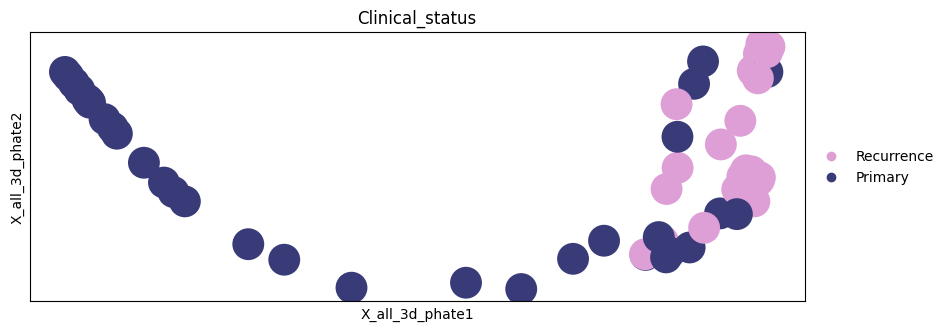

In [23]:
plt.rcParams["figure.figsize"] = (10, 3.5)
sc.pl.embedding(adata, 'X_all_3d_phate', color =['Clinical_status'], palette=['#de9ed6','#393b79'], save='beyond_DMG_only.pdf')

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


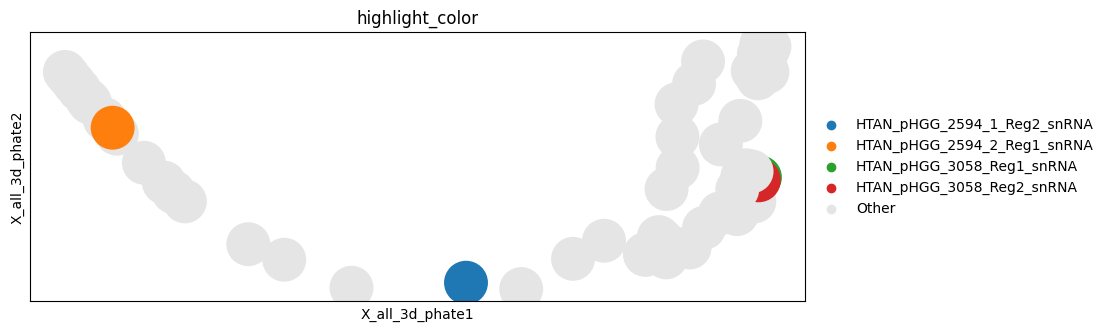

In [31]:
plt.rcParams["figure.figsize"] = (10, 3.5)
highlight_ids = [
    'HTAN_pHGG_2594_1_Reg2_snRNA', 'HTAN_pHGG_2594_2_Reg1_snRNA', 'HTAN_pHGG_3058_Reg1_snRNA',
    'HTAN_pHGG_3058_Reg2_snRNA'
]

# Create a new column 'highlight_color' where specific Patient IDs are colored
adata.obs['highlight_color'] = adata.obs['PatientIDdetail'].apply(
    lambda x: x if x in highlight_ids else 'Other'
)

# Define the palette with RGB colors for each highlighted Patient ID
palette = {
    'Other': '#e5e5e5',  # Light grey for other samples
    'HTAN_pHGG_2594_1_Reg2_snRNA': '#1f77b4',  # Blue
    'HTAN_pHGG_2594_2_Reg1_snRNA': '#ff7f0e',  # Orange
    'HTAN_pHGG_3058_Reg1_snRNA': '#2ca02c',    # Green
    'HTAN_pHGG_3058_Reg2_snRNA': '#d62728',    # Red
    'HTAN_pHGG_4347_Reg1_snRNA': '#9467bd',    # Purple
    'HTAN_pHGG_5928_Reg1_snRNA': '#8c564b',    # Brown
    'HTAN_pHGG_5928_Reg2_snRNA': '#e377c2',    # Pink
    'HTAN_pHGG_6761_Reg1_snRNA': '#7f7f7f',   # Grey
    'HTAN_pHGG_6761_Reg2_snRNA': '#bcbd22',    # Olive
    'HTAN_pHGG_7622_Reg1_snRNA': '#17becf',  # Cyan
    'HTAN_pHGG_7622_Reg2_snRNA': '#aec7e8',    # Light blue
    'T20-90296_472AAL_autopsy': '#ffbb78',     # Peach
    'T20-90296_472AAL_diagnosis': '#98df8a',   # Light green
    'T20-90296_472AAL_relapse': '#ff9896'      # Light red
}
# Plot with the custom color palette
sc.pl.embedding(
    adata[adata.obs['Tumor_type'].isin(['DMG H3 K27-altered'])],
    'X_all_3d_phate',
    color='highlight_color',
    palette=palette,
    legend_loc='right margin',
    size=4000,
    save='sussman_example_case_beyond.pdf'
)

/home/cruiz2/miniconda3/envs/r_env_standr/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


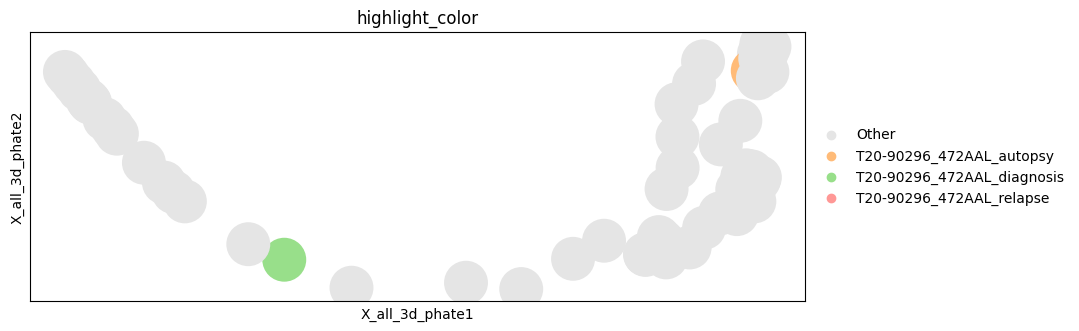

In [36]:
highlight_ids = [
    'T20-90296_472AAL_autopsy',
    'T20-90296_472AAL_diagnosis', 'T20-90296_472AAL_relapse'
]

# Create a new column 'highlight_color' where specific Patient IDs are colored
adata.obs['highlight_color'] = adata.obs['PatientIDdetail'].apply(
    lambda x: x if x in highlight_ids else 'Other'
)

# Define the palette with RGB colors for each highlighted Patient ID
palette = {
    'Other': '#e5e5e5',  # Light grey for other samples
    'HTAN_pHGG_2594_1_Reg2_snRNA': '#1f77b4',  # Blue
    'HTAN_pHGG_2594_2_Reg1_snRNA': '#ff7f0e',  # Orange
    'HTAN_pHGG_3058_Reg1_snRNA': '#2ca02c',    # Green
    'HTAN_pHGG_3058_Reg2_snRNA': '#d62728',    # Red
    'HTAN_pHGG_4347_Reg1_snRNA': '#9467bd',    # Purple
    'HTAN_pHGG_5928_Reg1_snRNA': '#8c564b',    # Brown
    'HTAN_pHGG_5928_Reg2_snRNA': '#e377c2',    # Pink
    'HTAN_pHGG_6761_Reg1_snRNA': '#7f7f7f',   # Grey
    'HTAN_pHGG_6761_Reg2_snRNA': '#bcbd22',    # Olive
    'HTAN_pHGG_7622_Reg1_snRNA': '#17becf',  # Cyan
    'HTAN_pHGG_7622_Reg2_snRNA': '#aec7e8',    # Light blue
    'T20-90296_472AAL_autopsy': '#ffbb78',     # Peach
    'T20-90296_472AAL_diagnosis': '#98df8a',   # Light green
    'T20-90296_472AAL_relapse': '#ff9896'      # Light red
}
# Plot with the custom color palette
sc.pl.embedding(
    adata[adata.obs['Tumor_type'].isin(['DMG H3 K27-altered'])],
    'X_all_3d_phate',
    color='highlight_color',
    palette=palette,
    legend_loc='right margin',
    size=4000,
    save='ruiz_example_case_beyond.pdf'
)